In [1]:
from __future__ import annotations

import sqlite3
import threading
import warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from datetime import timedelta
from io import StringIO
from pathlib import Path
from typing import Dict, List, Optional, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import requests
import yfinance as yf
from bs4 import BeautifulSoup

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

warnings.filterwarnings("ignore", category=FutureWarning)

/Users/kece/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [33]:
DEFAULT_DB_PATH   = Path.cwd() / ".backtest_cache" / "market_data.db"
RISK_FREE_TICKER  = "^IRX"          # 13-week T-bill annualised yield (÷100)
DEFAULT_BENCHMARK = "SPY"
TRADING_DAYS      = 756             # 3 years

In [34]:
@dataclass
class DataRequest:
    """
    Declare one price series a strategy needs.

    ticker   : Yahoo Finance symbol — e.g. "AAPL", "BTC-USD", "^GSPC"
    interval : yfinance interval string; "1d" is the only tested/recommended value
    fields   : OHLCV columns to keep; None → keep all
    lookback : extra *calendar* days to fetch before `start` for indicator
               warm-up.  This data is visible to generate_signals() but the
               equity curve only starts at `start`.
    """
    ticker:   str
    interval: str             = "1d"
    fields:   Optional[List[str]] = None
    lookback: int             = 756          # calendar days of warm-up


@dataclass
class UniverseRequest:
    """
    Optional: ask the engine to resolve index membership at each signal date.
    The resolved set of tickers is passed into generate_signals() as `universe`.

    index      : "SP500" → Wikipedia-based PIT S&P 500 membership
                 Anything else raises NotImplementedError (extend as needed).
    extra_data : DataRequest list for any tickers you always want in bundle
                 regardless of universe (e.g. a benchmark or risk-factor).
    """
    index:      str            = "SP500"
    extra_data: List[DataRequest] = field(default_factory=list)

In [35]:
class DataStore:
    """
    SQLite-backed price cache.  Keyed by (ticker, interval, date).
    Fetches only missing date ranges from yfinance; subsequent reads are local.

    Usage
    -----
    store = DataStore()                          # default path
    store = DataStore("/tmp/my_cache.db")        # custom path
    df    = store.get(DataRequest("AAPL"), "2018-01-01", "2024-01-01")
    store.info()                                 # show cached tickers
    store.clear_ticker("AAPL")                   # force re-fetch
    """

    def __init__(self, db_path: Optional[str | Path] = None):
        self.db_path = Path(db_path or DEFAULT_DB_PATH)
        self.db_path.parent.mkdir(parents=True, exist_ok=True)
        self._conn = sqlite3.connect(str(self.db_path), check_same_thread=False)
        self._lock = threading.Lock()
        self._init_schema()

    def _init_schema(self):
        with self._lock:
            self._conn.executescript("""
                CREATE TABLE IF NOT EXISTS price_cache (
                    ticker   TEXT NOT NULL,
                    interval TEXT NOT NULL,
                    date     TEXT NOT NULL,
                    open     REAL,
                    high     REAL,
                    low      REAL,
                    close    REAL,
                    volume   REAL,
                    PRIMARY KEY (ticker, interval, date)
                );
                CREATE TABLE IF NOT EXISTS cache_meta (
                    ticker   TEXT NOT NULL,
                    interval TEXT NOT NULL,
                    min_date TEXT,
                    max_date TEXT,
                    updated  TEXT,
                    PRIMARY KEY (ticker, interval)
                );
            """)
            self._conn.commit()


    def _meta(self, ticker: str, interval: str) -> Optional[dict]:
        cur = self._conn.execute(
            "SELECT min_date, max_date FROM cache_meta WHERE ticker=? AND interval=?",
            (ticker, interval),
        )
        row = cur.fetchone()
        return {"min_date": row[0], "max_date": row[1]} if row else None

    def _upsert(self, ticker: str, interval: str, df: pd.DataFrame):
        if df.empty:
            return
        rows = [
            (ticker, interval, str(dt.date()),
             _safe_float(r.get("Open")),  _safe_float(r.get("High")),
             _safe_float(r.get("Low")),   _safe_float(r.get("Close")),
             _safe_float(r.get("Volume")))
            for dt, r in df.iterrows()
        ]
        with self._lock:
            self._conn.executemany(
                "INSERT OR REPLACE INTO price_cache "
                "(ticker,interval,date,open,high,low,close,volume) VALUES(?,?,?,?,?,?,?,?)",
                rows,
            )
            self._conn.execute(
                "INSERT OR REPLACE INTO cache_meta(ticker,interval,min_date,max_date,updated) "
                "VALUES(?,?,?,?,datetime('now'))",
                (ticker, interval,
                 str(df.index.min().date()), str(df.index.max().date())),
            )
            self._conn.commit()

    def _read(self, ticker: str, interval: str, start: str, end: str) -> pd.DataFrame:
        cur = self._conn.execute(
            "SELECT date,open,high,low,close,volume FROM price_cache "
            "WHERE ticker=? AND interval=? AND date>=? AND date<=? ORDER BY date",
            (ticker, interval, start, end),
        )
        rows = cur.fetchall()
        if not rows:
            return pd.DataFrame()
        df = pd.DataFrame(rows, columns=["Date","Open","High","Low","Close","Volume"])
        df["Date"] = pd.to_datetime(df["Date"])
        return df.set_index("Date")

    def _fetch_yf(self, ticker: str, interval: str, start: str, end: str) -> pd.DataFrame:
        """Download from yfinance with auto-adjusted prices."""
        try:
            raw = yf.download(
                ticker, start=start, end=end,
                interval=interval, auto_adjust=True, progress=False,
            )
            if raw.empty:
                return pd.DataFrame()
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.index = pd.to_datetime(raw.index).tz_localize(None)
            return raw[["Open","High","Low","Close","Volume"]].dropna(how="all")
        except Exception as exc:
            print(f"[DataStore] yfinance error for {ticker}: {exc}")
            return pd.DataFrame()

    def get(self, req: DataRequest, start: str, end: str) -> pd.DataFrame:
        """
        Return OHLCV DataFrame for req.ticker from (start - lookback) to end.
        Only fetches the uncached portion from yfinance.
        """
        warmup_start = (
            pd.to_datetime(start) - timedelta(days=req.lookback)
        ).strftime("%Y-%m-%d")

        meta = self._meta(req.ticker, req.interval)

        # Determine what gaps (if any) need downloading
        gaps: List[Tuple[str, str]] = []
        if meta is None:
            gaps = [(warmup_start, end)]
        else:
            if warmup_start < meta["min_date"]:
                gaps.append((warmup_start, meta["min_date"]))
            if end > meta["max_date"]:
                gaps.append((meta["max_date"], end))

        for gap_start, gap_end in gaps:
            fresh = self._fetch_yf(req.ticker, req.interval, gap_start, gap_end)
            if not fresh.empty:
                self._upsert(req.ticker, req.interval, fresh)

        df = self._read(req.ticker, req.interval, warmup_start, end)

        if req.fields:
            available = [c for c in req.fields if c in df.columns]
            df = df[available]

        return df

    def clear_ticker(self, ticker: str, interval: str = "1d"):
        with self._lock:
            self._conn.execute(
                "DELETE FROM price_cache WHERE ticker=? AND interval=?", (ticker, interval))
            self._conn.execute(
                "DELETE FROM cache_meta WHERE ticker=? AND interval=?", (ticker, interval))
            self._conn.commit()
        print(f"[DataStore] Cleared {ticker} ({interval})")

    def info(self) -> pd.DataFrame:
        cur = self._conn.execute(
            "SELECT ticker,interval,min_date,max_date,updated FROM cache_meta ORDER BY ticker")
        return pd.DataFrame(
            cur.fetchall(), columns=["Ticker","Interval","From","To","Last Updated"])

In [36]:
_SP500_LOCK   = threading.Lock()
_SP500_LOADED = False
_SP500_CHANGES_DF:   Optional[pd.DataFrame] = None
_SP500_CURRENT_SET:  Optional[Set[str]]     = None
_WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
_WIKI_HDR = {"User-Agent": "Mozilla/5.0"}


def _load_sp500_pit():
    """
    Scrape Wikipedia's S&P 500 page and parse the historical changes table.
    Thread-safe; loads once per process.
    """
    global _SP500_LOADED, _SP500_CHANGES_DF, _SP500_CURRENT_SET

    if _SP500_LOADED:
        return

    with _SP500_LOCK:
        if _SP500_LOADED:
            return

        resp = requests.get(_WIKI_URL, headers=_WIKI_HDR, timeout=20)
        resp.raise_for_status()

        tables = pd.read_html(StringIO(resp.text))
        if len(tables) < 2:
            raise RuntimeError("Wikipedia S&P 500 table structure changed — update parser.")

        current_df  = tables[0]
        changes_raw = tables[1].copy()
        changes_raw.columns = [str(c).strip() for c in changes_raw.columns]

        date_col    = next(c for c in changes_raw.columns if "Effective" in c)
        added_col   = next(c for c in changes_raw.columns if "Added"   in c and "Ticker" in c)
        removed_col = next(c for c in changes_raw.columns if "Removed" in c and "Ticker" in c)

        ch = changes_raw[[date_col, added_col, removed_col]].copy()
        ch.columns = ["date", "added", "removed"]
        ch["date"]    = pd.to_datetime(ch["date"], errors="coerce")
        ch["added"]   = ch["added"].astype(str).str.strip()
        ch["removed"] = ch["removed"].astype(str).str.strip()
        ch = ch.dropna(subset=["date"]).reset_index(drop=True)

        _SP500_CURRENT_SET  = set(current_df["Symbol"].astype(str).str.strip())
        _SP500_CHANGES_DF   = ch
        _SP500_LOADED       = True


def sp500_members_on(date: str | pd.Timestamp) -> List[str]:
    """
    Return the list of S&P 500 tickers as of `date`.

    Survivorship-bias-free: starts from the *current* index and rewinds
    all changes that occurred after `date` (removing later additions,
    restoring later removals).

    Parameters
    ----------
    date : ISO date string or pd.Timestamp

    Returns
    -------
    Sorted list of Yahoo Finance ticker symbols (dots replaced by dashes).
    """
    _load_sp500_pit()
    assert _SP500_CURRENT_SET is not None
    assert _SP500_CHANGES_DF  is not None

    target = pd.to_datetime(date)
    members = set(_SP500_CURRENT_SET)

    # Rewind changes that happened AFTER target date
    future = (
        _SP500_CHANGES_DF[_SP500_CHANGES_DF["date"] > target]
        .sort_values("date", ascending=False)    # most recent first
    )

    for _, row in future.iterrows():
        added   = row["added"].strip()
        removed = row["removed"].strip()

        # This ticker was added AFTER target → it wasn't a member then
        if added and added not in ("nan", "None", ""):
            members.discard(added)

        # This ticker was removed AFTER target → it WAS a member then
        if removed and removed not in ("nan", "None", ""):
            members.add(removed)

class PITUniverseProvider:
    """
    Point-in-time universe resolver.  Caches per-date lookups in memory.

    Usage
    -----
    provider = PITUniverseProvider("SP500")
    members  = provider.members_on("2020-03-15")   # → List[str]
    """

    def __init__(self, index: str = "SP500"):
        if index != "SP500":
            raise NotImplementedError(
                f"Only 'SP500' is implemented.  Got '{index}'.")
        self._cache: Dict[str, List[str]] = {}

    def members_on(self, date: str | pd.Timestamp) -> List[str]:
        key = str(pd.to_datetime(date).date())
        if key not in self._cache:
            self._cache[key] = sp500_members_on(date)
        return self._cache[key]

In [37]:
class Strategy(ABC):
    """
    Subclass this and implement `required_data()` and `generate_signals()`.

    To opt into survivorship-bias-free universe resolution, also implement
    `required_universe()`.

    generate_signals() contract
    ───────────────────────────
    • `bundle` maps ticker → DataFrame(OHLCV) sliced to [:current_date].
      This slice is strictly look-ahead-free.
    • `current_date` is the bar being evaluated.
    • `universe` is a set of tickers confirmed to be in the index on
      current_date (only populated when required_universe() is implemented).
    • Return {ticker: weight}.  Weights should sum ≤ 1.0.
      Negative weights = short positions.  {} = 100% cash.
    """

    @abstractmethod
    def required_data(self) -> List[DataRequest]:
        """Declare every price series this strategy needs."""
        ...

    @abstractmethod
    def generate_signals(
        self,
        bundle: Dict[str, pd.DataFrame],
        current_date: pd.Timestamp,
        universe: Optional[Set[str]] = None,
    ) -> Dict[str, float]:
        """Return target portfolio weights for current_date."""
        ...

    def required_universe(self) -> Optional[UniverseRequest]:
        """
        Override to request a point-in-time universe.
        Return None (default) → no universe management.
        """
        return None

    def on_start(self, bundle: Dict[str, pd.DataFrame]):
        """Called once before the backtest loop begins."""

    def on_end(self, bundle: Dict[str, pd.DataFrame]):
        """Called once after the backtest loop ends."""

In [38]:
def _to_returns(equity: pd.Series) -> pd.Series:
    return equity.pct_change(fill_method=None).dropna()


def calc_cagr(equity: pd.Series) -> float:
    years = (equity.index[-1] - equity.index[0]).days / 365.25
    return (equity.iloc[-1] / equity.iloc[0]) ** (1 / years) - 1 if years > 0 else np.nan


def calc_sharpe(returns: pd.Series, rf_annual: float = 0.0) -> float:
    excess = returns - rf_annual / TRADING_DAYS
    std = excess.std()
    return (excess.mean() / std * np.sqrt(TRADING_DAYS)) if std > 0 else np.nan


def calc_sortino(returns: pd.Series, rf_annual: float = 0.0) -> float:
    excess   = returns - rf_annual / TRADING_DAYS
    downside = excess[excess < 0].std()
    return (excess.mean() / downside * np.sqrt(TRADING_DAYS)) if downside > 0 else np.nan


def calc_max_drawdown(equity: pd.Series) -> float:
    return ((equity - equity.cummax()) / equity.cummax()).min()


def calc_calmar(equity: pd.Series) -> float:
    mdd = abs(calc_max_drawdown(equity))
    return calc_cagr(equity) / mdd if mdd > 0 else np.nan


def calc_beta(port_ret: pd.Series, bench_ret: pd.Series) -> float:
    aligned = pd.concat([port_ret, bench_ret], axis=1).dropna()
    if len(aligned) < 10:
        return np.nan
    cov = aligned.iloc[:, 0].cov(aligned.iloc[:, 1])
    var = aligned.iloc[:, 1].var()
    return cov / var if var > 0 else np.nan


def calc_jensens_alpha(
    port_ret: pd.Series,
    bench_ret: pd.Series,
    rf_annual: float = 0.0,
) -> float:
    """
    Jensen's Alpha (annualised point estimate).
    α = E[Rp] - [Rf + β·(E[Rm] - Rf)]
    """
    b = calc_beta(port_ret, bench_ret)
    if np.isnan(b):
        return np.nan
    rf_d = rf_annual / TRADING_DAYS
    return (port_ret.mean() - (rf_d + b * (bench_ret.mean() - rf_d))) * TRADING_DAYS


def calc_information_ratio(port_ret: pd.Series, bench_ret: pd.Series) -> float:
    active = port_ret - bench_ret
    te = active.std()
    return (active.mean() / te * np.sqrt(TRADING_DAYS)) if te > 0 else np.nan


def calc_drawdown_series(equity: pd.Series) -> pd.Series:
    return (equity - equity.cummax()) / equity.cummax()


def calc_win_rate(returns: pd.Series) -> float:
    return float((returns > 0).mean())

In [39]:
class StatTests:
    """
    Full statistical test suite for a backtest result.

    Attributes (all computed lazily in __init__)
    ────────────────────────────────────────────
    alpha_ann       : Jensen's Alpha (annualised)
    alpha_tstat     : t-statistic on alpha (OLS CAPM regression)
    alpha_pval      : two-tailed p-value on alpha
    alpha_nw_tstat  : Newey-West HAC t-stat (robust to autocorrelation)
    alpha_nw_pval   : NW p-value
    beta            : market beta
    r_squared       : R² of CAPM regression
    excess_ir       : Information Ratio (excess return / tracking error)
    ir_tstat        : t-stat on mean excess return (NW HAC if available)
    ir_pval         : p-value on IR
    cagr_ci_lo      : 2.5th percentile bootstrap CAGR
    cagr_ci_hi      : 97.5th percentile bootstrap CAGR
    beat_years      : years strategy beat benchmark
    total_years     : total full calendar years in sample
    yoy_df          : year-by-year returns (strategy vs benchmark)
    """

    def __init__(
        self,
        port_ret:   pd.Series,
        bench_ret:  pd.Series,
        port_eq:    pd.Series,
        bench_eq:   pd.Series,
        rf_annual:  float = 0.0,
        n_bootstrap: int  = 2_000,
        nw_lags:    int   = 21,
    ):
        self.port_ret  = port_ret
        self.bench_ret = bench_ret
        self.rf_annual = rf_annual

        aligned = pd.concat([port_ret, bench_ret], axis=1).dropna()
        aligned.columns = ["rp", "rm"]
        n = len(aligned)

        # ── CAPM regression ───────────────────────────────────────────
        rf_d = rf_annual / TRADING_DAYS
        y = aligned["rp"] - rf_d
        x = aligned["rm"] - rf_d

        if HAS_STATSMODELS and n > 30:
            X  = sm.add_constant(x)
            ols = sm.OLS(y, X).fit()
            nw  = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})

            # statsmodels names params "const" and the regressor name
            alpha_key = ols.params.index[0]   # "const"
            beta_key  = ols.params.index[1]   # name of x series

            self.alpha_ann    = float(ols.params[alpha_key]) * TRADING_DAYS
            self.alpha_tstat  = float(ols.tvalues[alpha_key])
            self.alpha_pval   = float(ols.pvalues[alpha_key])
            self.alpha_nw_tstat = float(nw.tvalues[alpha_key])
            self.alpha_nw_pval  = float(nw.pvalues[alpha_key])
            self.beta         = float(ols.params[beta_key])
            self.r_squared    = float(ols.rsquared)

            # IR / excess return significance (NW)
            excess = aligned["rp"] - aligned["rm"]
            X2 = sm.add_constant(np.ones(n))
            nw2 = sm.OLS(excess.values, X2).fit(
                cov_type="HAC", cov_kwds={"maxlags": nw_lags})
            # nw2.params may be a plain ndarray (no named index)
            self.ir_tstat = float(nw2.tvalues[0])
            self.ir_pval  = float(nw2.pvalues[0])
        else:
            # Fallback: manual OLS
            beta_  = x.cov(y) / x.var() if x.var() > 0 else np.nan
            alpha_ = y.mean() - beta_ * x.mean()
            resid  = y - (alpha_ + beta_ * x)
            s2     = resid.var()
            sx2    = x.var()
            se_a   = np.sqrt(s2 / n + (x.mean() ** 2) * s2 / (n * sx2)) if sx2 > 0 else np.nan
            from scipy import stats as _stats
            self.alpha_ann    = alpha_ * TRADING_DAYS
            self.alpha_tstat  = alpha_ / se_a if se_a else np.nan
            self.alpha_pval   = 2 * _stats.t.sf(abs(self.alpha_tstat), df=n - 2)
            self.alpha_nw_tstat = self.alpha_tstat   # same (no HAC)
            self.alpha_nw_pval  = self.alpha_pval
            self.beta         = float(beta_)
            self.r_squared    = float(np.corrcoef(x, y)[0, 1] ** 2) if len(x) > 1 else np.nan
            excess = aligned["rp"] - aligned["rm"]
            te     = excess.std() * np.sqrt(TRADING_DAYS)
            ir_    = excess.mean() * TRADING_DAYS / te if te > 0 else 0
            se_ir  = 1 / np.sqrt(n / TRADING_DAYS)
            self.ir_tstat = ir_ / se_ir if se_ir else np.nan
            self.ir_pval  = 2 * _stats.norm.sf(abs(self.ir_tstat))

        self.excess_ir = calc_information_ratio(aligned["rp"], aligned["rm"])

        # ── Bootstrap CAGR confidence interval ───────────────────────
        np.random.seed(42)
        boot = [
            (np.prod(1 + np.random.choice(port_ret.values, size=len(port_ret), replace=True))
             ** (TRADING_DAYS / len(port_ret))) - 1
            for _ in range(n_bootstrap)
        ]
        self.cagr_ci_lo, self.cagr_ci_hi = float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))

        # ── Year-by-year ──────────────────────────────────────────────
        yoy_p = port_eq.resample("YE").last().pct_change(fill_method=None).dropna()
        yoy_b = bench_eq.resample("YE").last().pct_change(fill_method=None).dropna()
        yoy   = pd.concat([yoy_p, yoy_b], axis=1).dropna()
        yoy.columns = ["strategy", "benchmark"]
        yoy.index   = yoy.index.year
        self.yoy_df     = yoy
        self.beat_years = int((yoy["strategy"] > yoy["benchmark"]).sum())
        self.total_years = len(yoy)

    def summary_dict(self) -> dict:
        return {
            "Alpha (ann.)":          self.alpha_ann,
            "Alpha t-stat (OLS)":    self.alpha_tstat,
            "Alpha p-val  (OLS)":    self.alpha_pval,
            "Alpha t-stat (NW HAC)": self.alpha_nw_tstat,
            "Alpha p-val  (NW HAC)": self.alpha_nw_pval,
            "Beta":                  self.beta,
            "R²  (CAPM)":            self.r_squared,
            "Information Ratio":     self.excess_ir,
            "IR t-stat   (NW HAC)":  self.ir_tstat,
            "IR p-val    (NW HAC)":  self.ir_pval,
            "CAGR 95% CI (boot lo)": self.cagr_ci_lo,
            "CAGR 95% CI (boot hi)": self.cagr_ci_hi,
            f"Beat benchmark ({self.beat_years}/{self.total_years} yrs)": (
                self.beat_years / self.total_years if self.total_years else np.nan),
        }

In [40]:
class BacktestResult:
    """
    Holds equity curves, trade log, and all metrics.

    Attributes
    ----------
    equity           : portfolio value series (starts at initial_capital)
    benchmark_equity : benchmark value series (same start)
    trades           : DataFrame of every trade executed
    stats            : StatTests object with full significance analysis
    rf_annual        : average annualised risk-free rate used
    strategy_name    : class name of the strategy
    benchmark_ticker : ticker used as benchmark
    """

    def __init__(
        self,
        equity:           pd.Series,
        benchmark_equity: pd.Series,
        trades:           pd.DataFrame,
        rf_annual:        float,
        strategy_name:    str,
        benchmark_ticker: str,
        commission:       float,
        slippage:         float,
        execution_lag:    int,
    ):
        self.equity           = equity
        self.benchmark_equity = benchmark_equity
        self.trades           = trades
        self.rf_annual        = rf_annual
        self.strategy_name    = strategy_name
        self.benchmark_ticker = benchmark_ticker
        self.commission       = commission
        self.slippage         = slippage
        self.execution_lag    = execution_lag

        self._port_ret  = _to_returns(equity)
        self._bench_ret = _to_returns(benchmark_equity)

        # Statistical tests
        self.stats = StatTests(
            self._port_ret, self._bench_ret,
            equity, benchmark_equity, rf_annual,
        )

    # ── core metrics ──────────────────────────────────────────────────────────

    @property
    def metrics(self) -> dict:
        p  = self._port_ret
        b  = self._bench_ret
        rf = self.rf_annual
        return {
            "CAGR":                   calc_cagr(self.equity),
            "Benchmark CAGR":         calc_cagr(self.benchmark_equity),
            "Excess CAGR":            calc_cagr(self.equity) - calc_cagr(self.benchmark_equity),
            "Total Return":           self.equity.iloc[-1] / self.equity.iloc[0] - 1,
            "Benchmark Total Return": self.benchmark_equity.iloc[-1] / self.benchmark_equity.iloc[0] - 1,
            "Sharpe Ratio":           calc_sharpe(p, rf),
            "Sortino Ratio":          calc_sortino(p, rf),
            "Max Drawdown":           calc_max_drawdown(self.equity),
            "Benchmark Max Drawdown": calc_max_drawdown(self.benchmark_equity),
            "Calmar Ratio":           calc_calmar(self.equity),
            "Volatility (Ann.)":      p.std() * np.sqrt(TRADING_DAYS),
            "Win Rate":               calc_win_rate(p),
            "Num Trades":             len(self.trades),
            "Risk-Free Rate":         rf,
        }

    # ── summary print ─────────────────────────────────────────────────────────

    def summary(self) -> pd.DataFrame:
        """Print and return a formatted metrics + statistics table."""
        SEP = "═" * 52

        # Core metrics
        m = self.metrics
        fmt_map = {
            "CAGR":                   "{:>+.2%}",
            "Benchmark CAGR":         "{:>+.2%}",
            "Excess CAGR":            "{:>+.2%}",
            "Total Return":           "{:>+.2%}",
            "Benchmark Total Return": "{:>+.2%}",
            "Sharpe Ratio":           "{:>+.3f}",
            "Sortino Ratio":          "{:>+.3f}",
            "Max Drawdown":           "{:>.2%}",
            "Benchmark Max Drawdown": "{:>.2%}",
            "Calmar Ratio":           "{:>+.3f}",
            "Volatility (Ann.)":      "{:>.2%}",
            "Win Rate":               "{:>.2%}",
            "Num Trades":             "{:>.0f}",
            "Risk-Free Rate":         "{:>.2%}",
        }

        rows_m = []
        for k, v in m.items():
            try:
                rows_m.append({"Metric": k, "Value": fmt_map.get(k, "{}").format(v)})
            except Exception:
                rows_m.append({"Metric": k, "Value": str(v)})

        # Statistical tests
        st = self.stats.summary_dict()
        stat_fmt = {
            "Alpha (ann.)":           "{:>+.2%}",
            "Alpha t-stat (OLS)":     "{:>+.3f}",
            "Alpha p-val  (OLS)":     "{:>.4f}",
            "Alpha t-stat (NW HAC)":  "{:>+.3f}",
            "Alpha p-val  (NW HAC)":  "{:>.4f}",
            "Beta":                   "{:>.3f}",
            "R²  (CAPM)":             "{:>.3f}",
            "Information Ratio":      "{:>+.3f}",
            "IR t-stat   (NW HAC)":   "{:>+.3f}",
            "IR p-val    (NW HAC)":   "{:>.4f}",
            "CAGR 95% CI (boot lo)":  "{:>+.2%}",
            "CAGR 95% CI (boot hi)":  "{:>+.2%}",
        }
        rows_s = []
        for k, v in st.items():
            try:
                rows_s.append({"Metric": k, "Value": stat_fmt.get(k, "{:>.3f}").format(v)})
            except Exception:
                rows_s.append({"Metric": k, "Value": str(v)})

        print(f"\n{SEP}")
        print(f"  {self.strategy_name}  vs  {self.benchmark_ticker}")
        print(f"  Commission {self.commission:.2%}  |  Slippage {self.slippage:.3%}"
              f"  |  Exec lag {self.execution_lag}d")
        print(f"{SEP}")
        print("\n  ── PERFORMANCE ──")
        df_m = pd.DataFrame(rows_m).set_index("Metric")
        print(df_m.to_string())
        print("\n  ── STATISTICAL SIGNIFICANCE ──")
        df_s = pd.DataFrame(rows_s).set_index("Metric")
        print(df_s.to_string())

        # Year-by-year
        yoy = self.stats.yoy_df
        if not yoy.empty:
            print(f"\n  ── YEAR-BY-YEAR  "
                  f"(beat benchmark {self.stats.beat_years}/{self.stats.total_years} yrs) ──")
            print(f"  {'Year':<6} {'Strategy':>10} {'Benchmark':>10} {'Edge':>8}")
            print("  " + "-" * 36)
            for yr, row in yoy.iterrows():
                flag = "▲" if row["strategy"] > row["benchmark"] else "▼"
                print(f"  {yr:<6} {row['strategy']:>+9.1%} {row['benchmark']:>+9.1%}"
                      f" {row['strategy']-row['benchmark']:>+7.1%}  {flag}")
        print(f"{SEP}\n")

        return pd.concat([df_m, df_s])

    # ── plotting ──────────────────────────────────────────────────────────────

    def plot(
        self,
        figsize: Tuple[int, int] = (16, 11),
        save_path: Optional[str] = None,
        show: bool = True,
    ) -> plt.Figure:
        """
        Five-panel chart:
          1. Cumulative return (strategy vs benchmark) with alpha/outperformance shading
          2. Drawdown comparison
          3. Rolling 12-month excess return (alpha persistence)
          4. Year-by-year bar chart (strategy vs benchmark)
          5. Monthly return heatmap
        """
        C = {
            "bg":        "#0d1117",
            "panel":     "#161b22",
            "strategy":  "#00e5ff",
            "benchmark": "#ff6b35",
            "dd":        "#e53935",
            "pos":       "#00c853",
            "neg":       "#d50000",
            "neutral":   "#8b949e",
            "text":      "#c9d1d9",
            "grid":      "#21262d",
            "gold":      "#f0b429",
        }

        m      = self.metrics
        st     = self.stats
        p_ret  = self._port_ret
        b_ret  = self._bench_ret
        p_eq   = self.equity / self.equity.iloc[0]
        b_eq   = self.benchmark_equity / self.benchmark_equity.iloc[0]

        fig = plt.figure(figsize=figsize, facecolor=C["bg"])
        gs  = gridspec.GridSpec(
            3, 2, figure=fig,
            height_ratios=[2.5, 1.5, 1.8],
            hspace=0.48, wspace=0.28,
        )

        lag_note = "same-day close" if self.execution_lag == 0 else f"+{self.execution_lag}d close"
        fig.suptitle(
            f"{self.strategy_name}  •  "
            f"CAGR {m['CAGR']:+.1%} vs {self.benchmark_ticker} {m['Benchmark CAGR']:+.1%}  "
            f"|  α {st.alpha_ann:+.2%} (p={st.alpha_nw_pval:.3f} NW)  "
            f"|  Sharpe {m['Sharpe Ratio']:.2f}  "
            f"|  Exec: {lag_note}",
            color=C["text"], fontsize=10, y=0.99,
        )

        # ── 1: Cumulative return ──────────────────────────────────────
        ax1 = fig.add_subplot(gs[0, :])
        ax1.plot(p_eq.index, p_eq, color=C["strategy"],  lw=2.0,
                 label=f"{self.strategy_name}  {m['CAGR']:+.1%} CAGR", zorder=3)
        ax1.plot(b_eq.index, b_eq, color=C["benchmark"], lw=1.4, alpha=0.8,
                 label=f"{self.benchmark_ticker}  {m['Benchmark CAGR']:+.1%} CAGR", zorder=2)
        ax1.fill_between(p_eq.index, p_eq, b_eq,
                         where=p_eq >= b_eq, alpha=0.10, color=C["strategy"])
        ax1.fill_between(p_eq.index, p_eq, b_eq,
                         where=p_eq <  b_eq, alpha=0.10, color=C["benchmark"])
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.1f}×"))
        ax1.legend(loc="upper left", facecolor=C["panel"],
                   labelcolor=C["text"], fontsize=9, framealpha=0.9)
        _style_ax(ax1, C)

        # ── 2: Drawdown ───────────────────────────────────────────────
        ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
        dd_p = calc_drawdown_series(self.equity)
        dd_b = calc_drawdown_series(self.benchmark_equity)
        ax2.fill_between(dd_p.index, dd_p, 0, color=C["dd"],      alpha=0.5,
                         label=f"Strategy  {m['Max Drawdown']:.1%}")
        ax2.fill_between(dd_b.index, dd_b, 0, color=C["neutral"], alpha=0.3,
                         label=f"{self.benchmark_ticker}  {m['Benchmark Max Drawdown']:.1%}")
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax2.set_title("Drawdown", color=C["text"], fontsize=9, pad=5)
        ax2.legend(fontsize=8, facecolor=C["panel"], labelcolor=C["text"])
        _style_ax(ax2, C)

        # ── 3: Rolling 12m excess return ─────────────────────────────
        ax3 = fig.add_subplot(gs[1, 1], sharex=ax1)
        excess_r = (p_ret - b_ret).dropna()
        roll_exc = excess_r.rolling(TRADING_DAYS).mean() * TRADING_DAYS * 100
        ax3.plot(roll_exc.index, roll_exc, color=C["gold"], lw=1.4)
        ax3.axhline(0, color=C["text"], lw=0.6, alpha=0.4, ls="--")
        ax3.fill_between(roll_exc.index, roll_exc, 0,
                         where=roll_exc >= 0, color=C["pos"],  alpha=0.20)
        ax3.fill_between(roll_exc.index, roll_exc, 0,
                         where=roll_exc < 0,  color=C["neg"],  alpha=0.20)
        ax3.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:+.0f}%"))
        ax3.set_title(
            f"Rolling 12M Excess Return  "
            f"IR={st.excess_ir:+.2f}  "
            f"t={st.ir_tstat:+.2f}  p={st.ir_pval:.3f}",
            color=C["text"], fontsize=9, pad=5,
        )
        _style_ax(ax3, C)

        # ── 4: Year-by-year bars ──────────────────────────────────────
        ax4 = fig.add_subplot(gs[2, 0])
        yoy = st.yoy_df
        if not yoy.empty:
            x = np.arange(len(yoy)); w = 0.35
            bars_s = ax4.bar(x - w/2, yoy["strategy"] * 100, w,
                             color=[C["pos"] if v >= 0 else C["neg"]
                                    for v in yoy["strategy"]], alpha=0.85)
            ax4.bar(x + w/2, yoy["benchmark"] * 100, w,
                    color=C["benchmark"], alpha=0.55, label=self.benchmark_ticker)
            ax4.axhline(0, color=C["text"], lw=0.5, alpha=0.3)
            ax4.set_xticks(x)
            ax4.set_xticklabels(yoy.index, rotation=45, fontsize=7, color=C["text"])
            ax4.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:+.0f}%"))
            ax4.set_title(
                f"Year-by-Year  (beat {st.beat_years}/{st.total_years} yrs)",
                color=C["text"], fontsize=9, pad=5,
            )
            ax4.legend(fontsize=8, facecolor=C["panel"], labelcolor=C["text"])
        _style_ax(ax4, C)

        # ── 5: Monthly heatmap ────────────────────────────────────────
        ax5 = fig.add_subplot(gs[2, 1])
        _monthly_heatmap(ax5, p_ret, C)

        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight",
                        facecolor=fig.get_facecolor())
            print(f"[BacktestResult] Chart saved → {save_path}")
        if show:
            plt.show()

        return fig

In [41]:
class BacktestEngine:
    """
    Runs a strategy over a date range, producing a BacktestResult.

    Parameters
    ----------
    data_store      : shared DataStore (cache).  Created automatically if None.
    benchmark       : ticker for relative metrics (e.g. "SPY", "QQQ")
    initial_capital : starting NAV in USD
    commission      : fraction of trade value charged per leg
    slippage        : fractional price impact applied to each fill
    rebalance_freq  : "D"=daily, "W"=weekly, "ME"=month-end
    execution_lag   : 0 → fill at same-day close (MOC assumption)
                      1 → fill at next-day close (default, safer)
    """

    def __init__(
        self,
        data_store:      Optional[DataStore] = None,
        benchmark:       str   = DEFAULT_BENCHMARK,
        initial_capital: float = 10_000.0,
        commission:      float = 0.001,
        slippage:        float = 0.0005,
        rebalance_freq:  str   = "D",
        execution_lag:   int   = 1,
    ):
        self.store          = data_store or DataStore()
        self.benchmark      = benchmark
        self.capital        = initial_capital
        self.commission     = commission
        self.slippage       = slippage
        self.rebalance_freq = rebalance_freq
        self.execution_lag  = execution_lag

    # ── helpers ───────────────────────────────────────────────────────────────

    def _rf_rate(self, start: str, end: str) -> float:
        req = DataRequest(RISK_FREE_TICKER, lookback=0)
        try:
            df = self.store.get(req, start, end)
            return float(df["Close"].mean() / 100) if not df.empty else 0.04
        except Exception:
            return 0.04

    def _execute_trades(
        self,
        target_weights: Dict[str, float],
        prices: Dict[str, float],
        holdings: Dict[str, float],
        cash: float,
        nav: float,
        trade_log: list,
        dt: pd.Timestamp,
    ) -> Tuple[Dict[str, float], float]:
        """Apply target_weights → update holdings + cash.  Returns (holdings, cash)."""
        # Normalise: long weights must sum ≤ 1
        total_long = sum(max(w, 0) for w in target_weights.values())
        if total_long > 1.0:
            target_weights = {t: w / total_long for t, w in target_weights.items()}

        all_tickers = set(holdings) | set(target_weights)
        for t in all_tickers:
            if t not in prices:
                continue
            target_w   = target_weights.get(t, 0.0)
            target_val = nav * target_w
            target_shr = target_val / prices[t]
            delta_shr  = target_shr - holdings.get(t, 0.0)

            if abs(delta_shr) < 1e-8:
                continue

            direction  = 1 if delta_shr > 0 else -1
            exec_price = prices[t] * (1 + direction * self.slippage)
            trade_val  = abs(delta_shr) * exec_price
            cost       = trade_val * self.commission

            cash -= delta_shr * exec_price + direction * cost
            holdings[t] = holdings.get(t, 0.0) + delta_shr

            trade_log.append({
                "date":       dt,
                "ticker":     t,
                "direction":  "BUY" if delta_shr > 0 else "SELL",
                "shares":     delta_shr,
                "price":      exec_price,
                "value":      trade_val,
                "commission": cost,
            })

        return holdings, cash

    # ── main run ──────────────────────────────────────────────────────────────

    def run(
        self,
        strategy:   Strategy,
        start:      str,
        end:        str,
        verbose:    bool = True,
    ) -> BacktestResult:
        """
        Execute a full backtest.

        Bias controls applied
        ─────────────────────
        • Survivorship : if strategy.required_universe() returns a
          UniverseRequest, membership is resolved at each date via
          PITUniverseProvider.  Only PIT members are tradeable.
        • Look-ahead   : bundle is sliced to [:current_date].
          execution_lag (set on engine) delays fills appropriately.
        • Warmup data  : lookback days are fetched but equity curve
          starts at `start`, so warmup never inflates the period.
        """
        name = type(strategy).__name__
        if verbose:
            print(f"\n[BacktestEngine] ─── {name} | {start} → {end} ───")

        # ── 1. Resolve universe ───────────────────────────────────────
        universe_req = strategy.required_universe()
        pit_provider: Optional[PITUniverseProvider] = None
        if universe_req is not None:
            if verbose:
                print(f"[BacktestEngine] Loading PIT universe ({universe_req.index})…")
            pit_provider = PITUniverseProvider(universe_req.index)

        # ── 2. Fetch static data declared by strategy ─────────────────
        requests = strategy.required_data()
        if universe_req:
            requests = list(requests) + list(universe_req.extra_data)
        tickers = [r.ticker for r in requests]

        if verbose:
            print(f"[BacktestEngine] Fetching {len(tickers)} static ticker(s): {tickers}")
        bundle: Dict[str, pd.DataFrame] = {}
        for req in requests:
            bundle[req.ticker] = self.store.get(req, start, end)

        # ── 3. Benchmark & risk-free ──────────────────────────────────
        bench_req = DataRequest(self.benchmark, lookback=0)
        bench_df  = self.store.get(bench_req, start, end)
        rf_annual = self._rf_rate(start, end)

        if verbose:
            print(f"[BacktestEngine] Risk-free rate: {rf_annual:.2%}")

        # ── 4. Build trading calendar (intersection of all tickers) ───
        trade_idx: pd.DatetimeIndex = None  # type: ignore
        for df in bundle.values():
            idx = df.loc[start:end].index
            trade_idx = idx if trade_idx is None else trade_idx.intersection(idx)

        if trade_idx is None or len(trade_idx) == 0:
            raise ValueError("No overlapping trading days found for the requested tickers.")

        if self.rebalance_freq == "D":
            rebalance_dates = set(trade_idx)
        else:
            rebal = pd.Series(trade_idx, index=trade_idx).resample(self.rebalance_freq).last()
            rebalance_dates = set(rebal.dropna().values)

        # ── 5. Simulation loop ────────────────────────────────────────
        strategy.on_start(bundle)

        cash      = self.capital
        holdings: Dict[str, float] = {}
        last_px:  Dict[str, float] = {}
        equity_curve: List[Tuple[pd.Timestamp, float]] = []
        trade_log: List[dict] = []
        pending_weights: Optional[Dict[str, float]] = None  # for execution_lag

        for dt in trade_idx:
            # Current close prices for all tickers in bundle + any holdings
            prices: Dict[str, float] = {}
            for t in set(list(bundle.keys()) + list(holdings.keys())):
                df = bundle.get(t)
                if df is not None and dt in df.index:
                    v = df.loc[dt, "Close"]
                    if pd.notna(v) and v > 0:
                        prices[t] = float(v)
                        last_px[t] = float(v)
                elif t in last_px:
                    prices[t] = last_px[t]

            # NAV before today's trades
            nav = cash + sum(holdings.get(t, 0) * prices.get(t, 0)
                             for t in holdings)

            # Execute pending trades from previous day (if lag=1)
            if pending_weights is not None and self.execution_lag > 0:
                holdings, cash = self._execute_trades(
                    pending_weights, prices, holdings, cash, nav, trade_log, dt
                )
                pending_weights = None
                nav = cash + sum(holdings.get(t, 0) * prices.get(t, 0)
                                 for t in holdings)

            # Generate signals on rebalance dates
            if dt in rebalance_dates:
                # Point-in-time universe (survivorship bias fix)
                universe: Optional[Set[str]] = None
                if pit_provider is not None:
                    universe = set(pit_provider.members_on(dt))

                # Sliced bundle — look-ahead-free
                history = {t: df.loc[:dt] for t, df in bundle.items()}

                try:
                    target_weights = strategy.generate_signals(history, dt, universe)
                except Exception as exc:
                    if verbose:
                        print(f"[BacktestEngine] Signal error on {dt}: {exc}")
                    target_weights = {}

                if self.execution_lag == 0:
                    # Fill immediately at today's close
                    holdings, cash = self._execute_trades(
                        target_weights, prices, holdings, cash, nav, trade_log, dt
                    )
                else:
                    # Defer to next bar
                    pending_weights = target_weights

            # End-of-day NAV
            nav_eod = cash + sum(holdings.get(t, 0) * prices.get(t, 0)
                                 for t in holdings)
            equity_curve.append((dt, nav_eod))

        strategy.on_end(bundle)

        # ── 6. Build result ───────────────────────────────────────────
        eq = pd.Series(
            {dt: v for dt, v in equity_curve},
            name="Portfolio",
            dtype=float,
        )
        eq.index = pd.to_datetime(eq.index)

        bench_close  = bench_df["Close"].loc[start:end]
        bench_close  = bench_close.reindex(eq.index, method="ffill")
        bench_equity = bench_close / bench_close.iloc[0] * self.capital
        bench_equity.name = self.benchmark

        if verbose:
            n_days = len(equity_curve)
            cagr_  = calc_cagr(eq)
            print(f"[BacktestEngine] Done. {n_days} days | "
                  f"CAGR {cagr_:+.2%} | {len(trade_log)} trades")

        return BacktestResult(
            equity           = eq,
            benchmark_equity = bench_equity,
            trades           = pd.DataFrame(trade_log),
            rf_annual        = rf_annual,
            strategy_name    = name,
            benchmark_ticker = self.benchmark,
            commission       = self.commission,
            slippage         = self.slippage,
            execution_lag    = self.execution_lag,
        )

In [42]:
class WalkForwardEngine:
    """
    Splits the full period into rolling in-sample / out-of-sample windows
    and stitches the OOS segments into a single out-of-sample equity curve.

    This controls data-snooping bias: the reported CAGR reflects performance
    on data the strategy never "saw" during signal generation.

    Parameters
    ----------
    engine         : a configured BacktestEngine
    train_years    : length of in-sample window (years)
    test_years     : length of OOS window (years)
    anchored       : True → expanding training window (anchored start)
                     False → rolling training window
    """

    def __init__(
        self,
        engine:      BacktestEngine,
        train_years: float = 3.0,
        test_years:  float = 1.0,
        anchored:    bool  = True,
    ):
        self.engine      = engine
        self.train_years = train_years
        self.test_years  = test_years
        self.anchored    = anchored

    def run(
        self,
        strategy_factory,     # callable() → new Strategy instance each fold
        full_start: str,
        full_end:   str,
        verbose:    bool = True,
    ) -> Tuple[BacktestResult, List[BacktestResult]]:
        """
        Parameters
        ----------
        strategy_factory : zero-argument callable returning a fresh Strategy.
                           Example: lambda: SMACrossover("QQQ", fast=50, slow=200)
        full_start       : ISO start date of the entire period
        full_end         : ISO end date
        verbose          : print per-fold stats

        Returns
        -------
        oos_result  : BacktestResult built from stitched OOS segments
        fold_results : list of BacktestResult, one per fold (OOS segment only)
        """
        start = pd.Timestamp(full_start)
        end   = pd.Timestamp(full_end)
        train = pd.DateOffset(years=self.train_years)
        test  = pd.DateOffset(years=self.test_years)

        fold_results: List[BacktestResult] = []
        oos_eq_pieces: List[pd.Series] = []
        oos_bm_pieces: List[pd.Series] = []

        anchor = start
        fold_n = 0

        while True:
            train_start = anchor if self.anchored else anchor
            train_end   = anchor + train
            test_start  = train_end
            test_end    = test_start + test

            if test_end > end:
                break

            fold_n += 1
            ts = train_start.strftime("%Y-%m-%d")
            te = train_end.strftime("%Y-%m-%d")
            os = test_start.strftime("%Y-%m-%d")
            oe = test_end.strftime("%Y-%m-%d")

            if verbose:
                print(f"\n[WalkForward] Fold {fold_n}: "
                      f"train {ts}→{te}  |  OOS {os}→{oe}")

            # OOS backtest (strategy trained on historical data, tested on OOS)
            strat = strategy_factory()
            try:
                result = self.engine.run(strat, os, oe, verbose=False)
                fold_results.append(result)

                # Rescale OOS equity to chain continuously
                if oos_eq_pieces:
                    prev_end_val = oos_eq_pieces[-1].iloc[-1]
                else:
                    prev_end_val = self.engine.capital

                ratio = prev_end_val / result.equity.iloc[0]
                oos_eq_pieces.append(result.equity * ratio)
                oos_bm_pieces.append(result.benchmark_equity * ratio)

                if verbose:
                    c = calc_cagr(result.equity)
                    print(f"[WalkForward] Fold {fold_n} OOS CAGR: {c:+.2%}")

            except Exception as exc:
                if verbose:
                    print(f"[WalkForward] Fold {fold_n} failed: {exc}")

            # Advance window
            anchor = anchor + test

        if not oos_eq_pieces:
            raise RuntimeError("No folds completed. Extend the date range or shorten windows.")

        oos_eq = pd.concat(oos_eq_pieces).sort_index()
        oos_bm = pd.concat(oos_bm_pieces).sort_index()
        oos_bm.name = self.engine.benchmark

        rf = self.engine._rf_rate(full_start, full_end)

        oos_result = BacktestResult(
            equity           = oos_eq,
            benchmark_equity = oos_bm,
            trades           = pd.concat([r.trades for r in fold_results], ignore_index=True)
                               if fold_results else pd.DataFrame(),
            rf_annual        = rf,
            strategy_name    = f"{strategy_factory().__class__.__name__} [OOS WF]",
            benchmark_ticker = self.engine.benchmark,
            commission       = self.engine.commission,
            slippage         = self.engine.slippage,
            execution_lag    = self.engine.execution_lag,
        )

        if verbose:
            print(f"\n[WalkForward] {fold_n} folds complete")
            oos_cagr = calc_cagr(oos_eq)
            print(f"[WalkForward] Stitched OOS CAGR: {oos_cagr:+.2%}")

        return oos_result, fold_results

In [43]:
def _style_ax(ax, C: dict):
    ax.set_facecolor(C["panel"])
    ax.tick_params(colors=C["text"], labelsize=7)
    for spine in ax.spines.values():
        spine.set_color(C["grid"])
    ax.grid(True, color=C["grid"], lw=0.5, alpha=0.7)


def _monthly_heatmap(ax, daily_ret: pd.Series, C: dict):
    monthly = daily_ret.resample("ME").apply(lambda r: (1 + r).prod() - 1)
    if monthly.empty:
        ax.set_visible(False)
        return

    df = monthly.to_frame("ret")
    df["year"]  = df.index.year
    df["month"] = df.index.month

    years  = sorted(df["year"].unique())
    matrix = np.full((len(years), 12), np.nan)
    for _, row in df.iterrows():
        yi = years.index(int(row["year"]))
        mi = int(row["month"]) - 1
        matrix[yi, mi] = row["ret"]

    vmax = np.nanmax(np.abs(matrix)) or 0.05
    im = ax.imshow(matrix, aspect="auto", cmap="RdYlGn",
                   vmin=-vmax, vmax=vmax, alpha=0.85)

    ax.set_xticks(range(12))
    ax.set_xticklabels(
        ["J","F","M","A","M","J","J","A","S","O","N","D"],
        fontsize=7, color=C["text"])
    ax.set_yticks(range(len(years)))
    ax.set_yticklabels(years, fontsize=6, color=C["text"])
    ax.set_title("Monthly Returns", color=C["text"], fontsize=9, pad=5)
    ax.set_facecolor(C["panel"])
    for spine in ax.spines.values():
        spine.set_color(C["grid"])

    for yi in range(len(years)):
        for mi in range(12):
            v = matrix[yi, mi]
            if not np.isnan(v):
                ax.text(mi, yi, f"{v:.1%}", ha="center", va="center",
                        fontsize=4.5,
                        color="white" if abs(v) > vmax * 0.5 else C["text"])

    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02,
                 format=FuncFormatter(lambda x, _: f"{x:.0%}"))


# ══════════════════════════════════════════════════════════════════════════════
# MISC UTILITIES
# ══════════════════════════════════════════════════════════════════════════════

def _safe_float(v) -> float:
    try:
        f = float(v)
        return f if np.isfinite(f) else np.nan
    except (TypeError, ValueError):
        return np.nan


__all__ = [
    # Data layer
    "DataRequest", "UniverseRequest", "DataStore",
    # Survivorship bias
    "sp500_members_on", "PITUniverseProvider",
    # Strategy interface
    "Strategy",
    # Analytics
    "calc_cagr", "calc_sharpe", "calc_sortino", "calc_max_drawdown",
    "calc_calmar", "calc_beta", "calc_jensens_alpha", "calc_information_ratio",
    "calc_drawdown_series", "calc_win_rate",
    # Statistical tests
    "StatTests",
    # Results & engines
    "BacktestResult", "BacktestEngine", "WalkForwardEngine",
]


In [61]:
"""
══════════════════════════════════════════════════════════════════════════════

ONE CLASS.  Subclass `Backtest` and you're done.

    from backtest_framework import Backtest

    class MyStrategy(Backtest):
        benchmark     = "SPY"
        commission    = 0.001
        execution_lag = 1          # 0 = same-day close, 1 = next-day close

        def setup(self):
            self.add_ticker("AAPL", lookback=252)
            self.add_signals(df, date_col="date", ticker_col="ticker")

        def on_signal(self, date, signal, prices):
            self.enter(signal["ticker"], weight=0.10)

        def on_bar(self, date, prices):
            for tkr, pos in list(self.positions.items()):
                if pos.age_days >= 22:
                    self.exit(tkr)

    result = MyStrategy.run("2018-01-01", "2024-01-01")
    result.summary()
    result.plot()

──────────────────────────────────────────────────────────────────────────────
BIAS CONTROLS
──────────────────────────────────────────────────────────────────────────────
SURVIVORSHIP   add_universe("SP500") resolves membership at each signal date
               via PITUniverse (Wikipedia change-log rewind).
LOOK-AHEAD     self.data(ticker) returns history strictly up to current_date.
               execution_lag=1 (default) defers fills to next-day close.
               Signal rows are keyed by date — future rows are never visible.
DATA-SNOOPING  WalkForward stitches OOS-only segments into one equity curve.

──────────────────────────────────────────────────────────────────────────────
EXTERNAL DATA  (the main new feature)
──────────────────────────────────────────────────────────────────────────────
Any DataFrame can be registered as a signal source:

    self.add_signals(
        df,                      # PEAD signals, fundamentals, alt-data…
        date_col  = "entry_date",  # column holding the event date
        ticker_col= "Ticker",      # column holding the ticker (None if global)
        auto_fetch= True,          # download price data for every ticker in df
        lookback  = 0,
    )

For each simulation date, any rows in df where date_col == current_date
trigger on_signal(date, signal_dict, prices).  signal_dict is a plain
Python dict of the row — all your columns are available.

──────────────────────────────────────────────────────────────────────────────
TRADE API
──────────────────────────────────────────────────────────────────────────────
self.enter(ticker, weight=, dollars=, shares=, tag=)
self.exit(ticker, fraction=1.0)
self.exit_all()
self.set_weights(dict)

self.positions  → dict[ticker, Position]
self.cash       → float
self.nav        → float
self.prices     → dict[ticker, float]   today's closes
self.universe   → set[str] | None       PIT index members
self.date       → pd.Timestamp          current simulation date
self.data(t)    → pd.DataFrame          OHLCV up to self.date (look-ahead-free)
"""

from __future__ import annotations

import sqlite3
import threading
import warnings
from dataclasses import dataclass, field
from datetime import timedelta
from io import StringIO
from pathlib import Path
from typing import Any, Dict, List, Optional, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import requests

try:
    import yfinance as yf
    HAS_YF = True
except ImportError:
    HAS_YF = False
    warnings.warn("yfinance not installed — price downloads disabled.")

try:
    import statsmodels.api as sm
    HAS_SM = True
except ImportError:
    HAS_SM = False

warnings.filterwarnings("ignore", category=FutureWarning)


# ══════════════════════════════════════════════════════════════════════════════
# CONSTANTS
# ══════════════════════════════════════════════════════════════════════════════

DEFAULT_DB    = Path.cwd() / ".backtest_cache" / "market_data.db"
RF_TICKER     = "^IRX"
DEFAULT_BENCH = "SPY"
TDAYS         = 252


# ══════════════════════════════════════════════════════════════════════════════
# POSITION
# ══════════════════════════════════════════════════════════════════════════════

@dataclass
class Position:
    """Represents one open holding."""
    ticker:        str
    shares:        float
    entry_price:   float
    entry_date:    pd.Timestamp
    tag:           Optional[str] = None
    _current_price: float = field(default=0.0, repr=False)
    _age_days:      int   = field(default=0,   repr=False)

    @property
    def cost_basis(self) -> float:
        return self.shares * self.entry_price

    @property
    def market_value(self) -> float:
        return self.shares * self._current_price

    @property
    def unrealised_pnl(self) -> float:
        return self.market_value - self.cost_basis

    @property
    def unrealised_pct(self) -> float:
        return self._current_price / self.entry_price - 1 if self.entry_price else 0.0

    @property
    def age_days(self) -> int:
        return self._age_days

    def _update(self, price: float, current_date: pd.Timestamp):
        self._current_price = price
        self._age_days = (current_date - self.entry_date).days


# ══════════════════════════════════════════════════════════════════════════════
# DATA STORE
# ══════════════════════════════════════════════════════════════════════════════

class DataStore:
    """
    SQLite-backed OHLCV cache.  Only downloads uncached date ranges.

    store = DataStore()
    df    = store.get("AAPL", "2018-01-01", "2024-01-01", lookback=252)
    store.clear("AAPL")
    store.info()
    """

    def __init__(self, path: Optional[str | Path] = None):
        self.path = Path(path or DEFAULT_DB)
        self.path.parent.mkdir(parents=True, exist_ok=True)
        self._conn = sqlite3.connect(str(self.path), check_same_thread=False)
        self._lock = threading.Lock()
        self._setup()

    def _setup(self):
        self._conn.executescript("""
            CREATE TABLE IF NOT EXISTS prices (
                ticker TEXT, interval TEXT, date TEXT,
                open REAL, high REAL, low REAL, close REAL, volume REAL,
                PRIMARY KEY (ticker, interval, date)
            );
            CREATE TABLE IF NOT EXISTS meta (
                ticker TEXT, interval TEXT,
                min_date TEXT, max_date TEXT, updated TEXT,
                PRIMARY KEY (ticker, interval)
            );
        """)
        self._conn.commit()

    def _meta(self, ticker: str, interval: str) -> Optional[dict]:
        cur = self._conn.execute(
            "SELECT min_date, max_date FROM meta WHERE ticker=? AND interval=?",
            (ticker, interval))
        row = cur.fetchone()
        return {"min": row[0], "max": row[1]} if row else None

    def _upsert(self, ticker: str, interval: str, df: pd.DataFrame):
        if df.empty:
            return
        rows = [(ticker, interval, str(dt.date()),
                 _f(r.get("Open")), _f(r.get("High")),
                 _f(r.get("Low")),  _f(r.get("Close")), _f(r.get("Volume")))
                for dt, r in df.iterrows()]
        with self._lock:
            self._conn.executemany(
                "INSERT OR REPLACE INTO prices VALUES(?,?,?,?,?,?,?,?)", rows)
            self._conn.execute(
                "INSERT OR REPLACE INTO meta VALUES(?,?,?,?,datetime('now'))",
                (ticker, interval,
                 str(df.index.min().date()), str(df.index.max().date())))
            self._conn.commit()

    def _read(self, ticker: str, interval: str, start: str, end: str) -> pd.DataFrame:
        cur = self._conn.execute(
            "SELECT date,open,high,low,close,volume FROM prices "
            "WHERE ticker=? AND interval=? AND date>=? AND date<=? ORDER BY date",
            (ticker, interval, start, end))
        rows = cur.fetchall()
        if not rows:
            return pd.DataFrame()
        df = pd.DataFrame(rows, columns=["Date","Open","High","Low","Close","Volume"])
        df["Date"] = pd.to_datetime(df["Date"])
        return df.set_index("Date")

    def _download(self, ticker: str, interval: str, start: str, end: str) -> pd.DataFrame:
        if not HAS_YF:
            return pd.DataFrame()
        try:
            raw = yf.download(ticker, start=start, end=end,
                              interval=interval, auto_adjust=True, progress=False)
            if raw.empty:
                return pd.DataFrame()
            if isinstance(raw.columns, pd.MultiIndex):
                raw.columns = raw.columns.get_level_values(0)
            raw.index = pd.to_datetime(raw.index).tz_localize(None)
            return raw[["Open","High","Low","Close","Volume"]].dropna(how="all")
        except Exception as e:
            print(f"  [DataStore] yfinance error {ticker}: {e}")
            return pd.DataFrame()

    def get(self, ticker: str, start: str, end: str,
            lookback: int = 0, interval: str = "1d") -> pd.DataFrame:
        """Return OHLCV, fetching only uncached ranges from yfinance."""
        warmup = (pd.to_datetime(start) - timedelta(days=lookback)).strftime("%Y-%m-%d")
        meta   = self._meta(ticker, interval)
        gaps: List[Tuple[str, str]] = []
        if meta is None:
            gaps = [(warmup, end)]
        else:
            if warmup < meta["min"]:
                gaps.append((warmup, meta["min"]))
            if end > meta["max"]:
                gaps.append((meta["max"], end))
        for gs, ge in gaps:
            self._upsert(ticker, interval, self._download(ticker, interval, gs, ge))
        return self._read(ticker, interval, warmup, end)

    def prefetch(self, tickers: List[str], start: str, end: str,
                 lookback: int = 0, interval: str = "1d"):
        """Batch download, skipping tickers already fully cached."""
        new     = [t for t in tickers if self._meta(t, interval) is None]
        cached  = len(tickers) - len(new)
        if cached:
            print(f"  [DataStore] {cached}/{len(tickers)} already cached")
        if new:
            print(f"  [DataStore] Fetching {len(new)} new tickers…")
            warmup = (pd.to_datetime(start) - timedelta(days=lookback)).strftime("%Y-%m-%d")
            for i, t in enumerate(new, 1):
                df = self._download(t, interval, warmup, end)
                if not df.empty:
                    self._upsert(t, interval, df)
                if i % 50 == 0:
                    print(f"    {i}/{len(new)}")

    def clear(self, ticker: str, interval: str = "1d"):
        with self._lock:
            self._conn.execute(
                "DELETE FROM prices WHERE ticker=? AND interval=?", (ticker, interval))
            self._conn.execute(
                "DELETE FROM meta WHERE ticker=? AND interval=?", (ticker, interval))
            self._conn.commit()

    def info(self) -> pd.DataFrame:
        cur = self._conn.execute(
            "SELECT ticker,interval,min_date,max_date,updated FROM meta ORDER BY ticker")
        return pd.DataFrame(cur.fetchall(),
                            columns=["Ticker","Interval","From","To","Updated"])


# ══════════════════════════════════════════════════════════════════════════════
# SURVIVORSHIP BIAS — Point-in-time S&P 500 membership
# ══════════════════════════════════════════════════════════════════════════════

_PIT_LOCK    = threading.Lock()
_PIT_LOADED  = False
_PIT_CHANGES: Optional[pd.DataFrame] = None
_PIT_CURRENT: Optional[Set[str]]     = None
_WIKI_URL = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"


def _load_pit():
    global _PIT_LOADED, _PIT_CHANGES, _PIT_CURRENT
    if _PIT_LOADED:
        return
    with _PIT_LOCK:
        if _PIT_LOADED:
            return
        resp = requests.get(_WIKI_URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=20)
        resp.raise_for_status()
        tables = pd.read_html(StringIO(resp.text))
        if len(tables) < 2:
            raise RuntimeError("Wikipedia S&P 500 table structure changed.")
        cur = tables[0]
        ch  = tables[1].copy()
        ch.columns = [str(c).strip() for c in ch.columns]
        dc = next(c for c in ch.columns if "Effective" in c)
        ac = next(c for c in ch.columns if "Added"   in c and "Ticker" in c)
        rc = next(c for c in ch.columns if "Removed" in c and "Ticker" in c)
        ch = ch[[dc, ac, rc]].copy()
        ch.columns = ["date","added","removed"]
        ch["date"]    = pd.to_datetime(ch["date"], errors="coerce")
        ch["added"]   = ch["added"].astype(str).str.strip()
        ch["removed"] = ch["removed"].astype(str).str.strip()
        ch = ch.dropna(subset=["date"]).reset_index(drop=True)
        _PIT_CURRENT = set(cur["Symbol"].astype(str).str.strip())
        _PIT_CHANGES = ch
        _PIT_LOADED  = True


def sp500_on(date) -> List[str]:
    """
    Return S&P 500 tickers as of `date`, survivorship-bias-free.
    Rewinds the full change log from the current index back to the target date.
    """
    _load_pit()
    target  = pd.to_datetime(date)
    members = set(_PIT_CURRENT)  # type: ignore[arg-type]
    future  = (_PIT_CHANGES[_PIT_CHANGES["date"] > target]  # type: ignore[index]
               .sort_values("date", ascending=False))
    for _, row in future.iterrows():
        a, r = row["added"], row["removed"]
        if a and a not in ("nan","None",""):
            members.discard(a)
        if r and r not in ("nan","None",""):
            members.add(r)
    return sorted(t.replace(".", "-") for t in members)


class PITUniverse:
    """Cached per-date S&P 500 PIT membership lookups."""
    def __init__(self):
        self._cache: Dict[str, List[str]] = {}

    def on(self, date) -> List[str]:
        key = str(pd.to_datetime(date).date())
        if key not in self._cache:
            self._cache[key] = sp500_on(date)
        return self._cache[key]


# ══════════════════════════════════════════════════════════════════════════════
# ANALYTICS
# ══════════════════════════════════════════════════════════════════════════════

def _ret(eq: pd.Series) -> pd.Series:
    return eq.pct_change(fill_method=None).dropna()

def cagr(eq: pd.Series) -> float:
    yrs = (eq.index[-1] - eq.index[0]).days / 365.25
    return (eq.iloc[-1] / eq.iloc[0]) ** (1/yrs) - 1 if yrs > 0 else np.nan

def sharpe(r: pd.Series, rf: float = 0.0) -> float:
    exc = r - rf/TDAYS
    return (exc.mean()/exc.std()*np.sqrt(TDAYS)) if exc.std() > 0 else np.nan

def sortino(r: pd.Series, rf: float = 0.0) -> float:
    exc = r - rf/TDAYS
    d   = exc[exc < 0].std()
    return (exc.mean()/d*np.sqrt(TDAYS)) if d > 0 else np.nan

def max_dd(eq: pd.Series) -> float:
    return ((eq - eq.cummax()) / eq.cummax()).min()

def calmar(eq: pd.Series) -> float:
    mdd = abs(max_dd(eq))
    return cagr(eq)/mdd if mdd > 0 else np.nan

def beta(rp: pd.Series, rb: pd.Series) -> float:
    al = pd.concat([rp, rb], axis=1).dropna()
    if len(al) < 10:
        return np.nan
    return al.iloc[:,0].cov(al.iloc[:,1]) / al.iloc[:,1].var()

def jensens_alpha(rp: pd.Series, rb: pd.Series, rf: float = 0.0) -> float:
    b = beta(rp, rb)
    if np.isnan(b):
        return np.nan
    rf_d = rf / TDAYS
    return (rp.mean() - (rf_d + b*(rb.mean()-rf_d))) * TDAYS

def info_ratio(rp: pd.Series, rb: pd.Series) -> float:
    act = rp - rb
    te  = act.std()
    return (act.mean()/te*np.sqrt(TDAYS)) if te > 0 else np.nan

def dd_series(eq: pd.Series) -> pd.Series:
    return (eq - eq.cummax()) / eq.cummax()


# ══════════════════════════════════════════════════════════════════════════════
# STATISTICAL SIGNIFICANCE
# ══════════════════════════════════════════════════════════════════════════════

class Stats:
    """
    CAPM OLS alpha, Newey-West HAC alpha, IR, bootstrap CAGR CI, year-by-year.
    """

    def __init__(self, rp: pd.Series, rb: pd.Series,
                 eq: pd.Series, bq: pd.Series,
                 rf: float = 0.0, n_boot: int = 2_000, nw_lags: int = 21):

        al = pd.concat([rp, rb], axis=1).dropna()
        al.columns = ["rp","rb"]
        n    = len(al)
        rf_d = rf / TDAYS
        y    = al["rp"] - rf_d
        x    = al["rb"] - rf_d

        if HAS_SM and n > 30:
            X   = sm.add_constant(x)
            ols = sm.OLS(y, X).fit()
            nw  = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
            ak  = ols.params.index[0]
            bk  = ols.params.index[1]
            self.alpha_ann  = float(ols.params[ak]) * TDAYS
            self.alpha_t    = float(ols.tvalues[ak])
            self.alpha_p    = float(ols.pvalues[ak])
            self.alpha_nw_t = float(nw.tvalues[ak])
            self.alpha_nw_p = float(nw.pvalues[ak])
            self.beta_      = float(ols.params[bk])
            self.r2         = float(ols.rsquared)
            exc = al["rp"] - al["rb"]
            X2  = sm.add_constant(np.ones(n))
            nw2 = sm.OLS(exc.values, X2).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
            self.ir_t = float(nw2.tvalues[0])
            self.ir_p = float(nw2.pvalues[0])
        else:
            from scipy import stats as sp
            b_  = x.cov(y) / x.var() if x.var() > 0 else np.nan
            a_  = y.mean() - b_ * x.mean()
            res = y - (a_ + b_*x)
            se  = np.sqrt(res.var() / n) if n > 2 else np.nan
            self.alpha_ann  = a_ * TDAYS
            self.alpha_t    = a_/se if se else np.nan
            self.alpha_p    = 2*sp.t.sf(abs(self.alpha_t), df=n-2)
            self.alpha_nw_t = self.alpha_t
            self.alpha_nw_p = self.alpha_p
            self.beta_      = float(b_)
            self.r2         = float(np.corrcoef(x,y)[0,1]**2) if n > 1 else np.nan
            exc = al["rp"] - al["rb"]
            te  = exc.std()*np.sqrt(TDAYS)
            ir_ = exc.mean()*TDAYS/te if te > 0 else 0
            se_ir = 1/np.sqrt(n/TDAYS)
            self.ir_t = ir_/se_ir if se_ir else np.nan
            self.ir_p = 2*sp.norm.sf(abs(self.ir_t))

        self.ir = info_ratio(al["rp"], al["rb"])

        np.random.seed(42)
        boot = [(np.prod(1+np.random.choice(rp.values, len(rp), replace=True))
                 **(TDAYS/len(rp)))-1 for _ in range(n_boot)]
        self.ci_lo, self.ci_hi = float(np.percentile(boot,2.5)), float(np.percentile(boot,97.5))

        yp = eq.resample("YE").last().pct_change(fill_method=None).dropna()
        yb = bq.resample("YE").last().pct_change(fill_method=None).dropna()
        yy = pd.concat([yp, yb], axis=1).dropna()
        yy.columns = ["strategy","benchmark"]
        yy.index = yy.index.year
        self.yoy         = yy
        self.beat_years  = int((yy["strategy"] > yy["benchmark"]).sum())
        self.total_years = len(yy)


# ══════════════════════════════════════════════════════════════════════════════
# RESULT
# ══════════════════════════════════════════════════════════════════════════════

class Result:
    """Returned by Backtest.run(). Call .summary() and .plot()."""

    def __init__(self, equity: pd.Series, benchmark: pd.Series,
                 trades: pd.DataFrame, rf: float,
                 name: str, bench_name: str,
                 commission: float, slippage: float, lag: int):
        self.equity    = equity
        self.benchmark = benchmark
        self.trades    = trades
        self.rf        = rf
        self.name      = name
        self.bench_name= bench_name
        self.commission= commission
        self.slippage  = slippage
        self.lag       = lag
        self._rp = _ret(equity)
        self._rb = _ret(benchmark)
        self.stats = Stats(self._rp, self._rb, equity, benchmark, rf)

    @property
    def metrics(self) -> dict:
        s = self.stats
        return {
            "CAGR":                   cagr(self.equity),
            "Benchmark CAGR":         cagr(self.benchmark),
            "Excess CAGR":            cagr(self.equity) - cagr(self.benchmark),
            "Total Return":           self.equity.iloc[-1]/self.equity.iloc[0]-1,
            "Benchmark Total Return": self.benchmark.iloc[-1]/self.benchmark.iloc[0]-1,
            "Sharpe Ratio":           sharpe(self._rp, self.rf),
            "Sortino Ratio":          sortino(self._rp, self.rf),
            "Max Drawdown":           max_dd(self.equity),
            "Benchmark Max Drawdown": max_dd(self.benchmark),
            "Calmar Ratio":           calmar(self.equity),
            "Volatility (ann.)":      self._rp.std()*np.sqrt(TDAYS),
            "Win Rate":               float((self._rp > 0).mean()),
            "Num Trades":             len(self.trades),
            "Risk-Free Rate":         self.rf,
            "Jensen's Alpha":         s.alpha_ann,
            "Alpha t (OLS)":          s.alpha_t,
            "Alpha p (OLS)":          s.alpha_p,
            "Alpha t (NW HAC)":       s.alpha_nw_t,
            "Alpha p (NW HAC)":       s.alpha_nw_p,
            "Beta":                   s.beta_,
            "R² (CAPM)":              s.r2,
            "Information Ratio":      s.ir,
            "IR t (NW HAC)":          s.ir_t,
            "IR p (NW HAC)":          s.ir_p,
            "CAGR CI lo (95% boot)":  s.ci_lo,
            "CAGR CI hi (95% boot)":  s.ci_hi,
        }

    def summary(self) -> "Result":
        m, s = self.metrics, self.stats
        SEP  = "═" * 54
        pct  = lambda v: f"{v:>+.2%}"
        f3   = lambda v: f"{v:>+.3f}"

        perf = [
            ("CAGR",                   pct(m["CAGR"])),
            ("CAGR 95% CI (boot)",     f"[{pct(s.ci_lo)}, {pct(s.ci_hi)}]"),
            ("Benchmark CAGR",         pct(m["Benchmark CAGR"])),
            ("Excess CAGR",            pct(m["Excess CAGR"])),
            ("Total Return",           pct(m["Total Return"])),
            ("Sharpe Ratio",           f3(m["Sharpe Ratio"])),
            ("Sortino Ratio",          f3(m["Sortino Ratio"])),
            ("Calmar Ratio",           f3(m["Calmar Ratio"])),
            ("Max Drawdown",           f"{m['Max Drawdown']:>.2%}"),
            ("Benchmark Max Drawdown", f"{m['Benchmark Max Drawdown']:>.2%}"),
            ("Volatility (ann.)",      f"{m['Volatility (ann.)']:>.2%}"),
            ("Win Rate",               f"{m['Win Rate']:>.2%}"),
            ("Num Trades",             str(int(m["Num Trades"]))),
        ]
        sig = [
            ("Jensen's Alpha",       pct(m["Jensen's Alpha"])),
            ("Alpha t / p (OLS)",    f"{m['Alpha t (OLS)']:>+.3f}  /  {m['Alpha p (OLS)']:.4f}"),
            ("Alpha t / p (NW HAC)", f"{m['Alpha t (NW HAC)']:>+.3f}  /  {m['Alpha p (NW HAC)']:.4f}"),
            ("Beta",                 f3(m["Beta"])),
            ("R² (CAPM)",            f"{m['R² (CAPM)']:.3f}"),
            ("Information Ratio",    f3(m["Information Ratio"])),
            ("IR t / p (NW HAC)",    f"{m['IR t (NW HAC)']:>+.3f}  /  {m['IR p (NW HAC)']:.4f}"),
        ]

        print(f"\n{SEP}")
        print(f"  {self.name}  ▸  {self.bench_name}")
        print(f"  commission={self.commission:.2%}  slippage={self.slippage:.3%}  lag={self.lag}d")
        print(f"{SEP}")
        print("  ── PERFORMANCE ──")
        for k, v in perf:
            print(f"  {k:<30} {v}")
        print("  ── SIGNIFICANCE ──")
        for k, v in sig:
            print(f"  {k:<30} {v}")
        if not s.yoy.empty:
            print(f"  ── YEAR-BY-YEAR  (beat {s.beat_years}/{s.total_years}) ──")
            print(f"  {'Year':<6} {'Strategy':>10} {'Benchmark':>10} {'Edge':>8}")
            for yr, row in s.yoy.iterrows():
                sym = "▲" if row["strategy"] > row["benchmark"] else "▼"
                print(f"  {yr:<6} {row['strategy']:>+9.1%} {row['benchmark']:>+9.1%}"
                      f" {row['strategy']-row['benchmark']:>+7.1%}  {sym}")
        print(f"{SEP}\n")
        return self

    def plot(self, save_path: Optional[str] = None, show: bool = True,
             figsize: Tuple[int,int] = (16,11)) -> "Result":
        C = dict(bg="#0d1117", panel="#161b22", strat="#00e5ff",
                 bench="#ff6b35", dd="#e53935", pos="#00c853",
                 neg="#d50000", neutral="#8b949e", text="#c9d1d9",
                 grid="#21262d", gold="#f0b429")

        s   = self.stats
        m   = self.metrics
        peq = self.equity / self.equity.iloc[0]
        beq = self.benchmark / self.benchmark.iloc[0]

        fig = plt.figure(figsize=figsize, facecolor=C["bg"])
        gs  = gridspec.GridSpec(3,2, figure=fig,
                                height_ratios=[2.5,1.5,1.8],
                                hspace=0.48, wspace=0.28)

        nw_sig = "★" if s.alpha_nw_p < 0.05 else ""
        fig.suptitle(
            f"{self.name}  ▸  "
            f"CAGR {m['CAGR']:+.1%} vs {self.bench_name} {m['Benchmark CAGR']:+.1%}  |  "
            f"α {s.alpha_ann:+.2%} (NW p={s.alpha_nw_p:.3f}{nw_sig})  |  "
            f"Sharpe {m['Sharpe Ratio']:.2f}  |  lag={self.lag}d",
            color=C["text"], fontsize=10, y=0.99)

        ax1 = fig.add_subplot(gs[0,:])
        ax1.plot(peq.index, peq, color=C["strat"], lw=2.0,
                 label=f"{self.name}  {m['CAGR']:+.1%}")
        ax1.plot(beq.index, beq, color=C["bench"], lw=1.4, alpha=0.8,
                 label=f"{self.bench_name}  {m['Benchmark CAGR']:+.1%}")
        ax1.fill_between(peq.index, peq, beq, where=peq>=beq,
                         color=C["strat"], alpha=0.10)
        ax1.fill_between(peq.index, peq, beq, where=peq<beq,
                         color=C["bench"], alpha=0.10)
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:.1f}×"))
        ax1.legend(loc="upper left", facecolor=C["panel"],
                   labelcolor=C["text"], fontsize=9)
        _sax(ax1, C)

        ax2 = fig.add_subplot(gs[1,0], sharex=ax1)
        ddp = dd_series(self.equity)
        ddb = dd_series(self.benchmark)
        ax2.fill_between(ddp.index, ddp, 0, color=C["dd"],      alpha=0.5,
                         label=f"Strategy  {m['Max Drawdown']:.1%}")
        ax2.fill_between(ddb.index, ddb, 0, color=C["neutral"], alpha=0.3,
                         label=f"{self.bench_name}  {m['Benchmark Max Drawdown']:.1%}")
        ax2.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:.0%}"))
        ax2.set_title("Drawdown", color=C["text"], fontsize=9, pad=5)
        ax2.legend(fontsize=8, facecolor=C["panel"], labelcolor=C["text"])
        _sax(ax2, C)

        ax3 = fig.add_subplot(gs[1,1], sharex=ax1)
        exc  = (self._rp - self._rb).dropna()
        roll = exc.rolling(TDAYS).mean()*TDAYS*100
        ax3.plot(roll.index, roll, color=C["gold"], lw=1.4)
        ax3.axhline(0, color=C["text"], lw=0.6, alpha=0.4, ls="--")
        ax3.fill_between(roll.index, roll, 0, where=roll>=0, color=C["pos"], alpha=0.20)
        ax3.fill_between(roll.index, roll, 0, where=roll< 0, color=C["neg"], alpha=0.20)
        ax3.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:+.0f}%"))
        ax3.set_title(f"Rolling 12M Excess  IR={s.ir:+.2f}  t={s.ir_t:+.2f}  p={s.ir_p:.3f}",
                      color=C["text"], fontsize=9, pad=5)
        _sax(ax3, C)

        ax4 = fig.add_subplot(gs[2,0])
        yy  = s.yoy
        if not yy.empty:
            x = np.arange(len(yy)); w = 0.35
            ax4.bar(x-w/2, yy["strategy"]*100, w, alpha=0.85,
                    color=[C["pos"] if v>=0 else C["neg"] for v in yy["strategy"]])
            ax4.bar(x+w/2, yy["benchmark"]*100, w, alpha=0.55,
                    color=C["bench"], label=self.bench_name)
            ax4.axhline(0, color=C["text"], lw=0.5, alpha=0.3)
            ax4.set_xticks(x)
            ax4.set_xticklabels(yy.index, rotation=45, fontsize=7, color=C["text"])
            ax4.yaxis.set_major_formatter(FuncFormatter(lambda x,_: f"{x:+.0f}%"))
            ax4.set_title(f"Year-by-Year  (beat {s.beat_years}/{s.total_years})",
                          color=C["text"], fontsize=9, pad=5)
            ax4.legend(fontsize=8, facecolor=C["panel"], labelcolor=C["text"])
        _sax(ax4, C)

        ax5 = fig.add_subplot(gs[2,1])
        _heatmap(ax5, self._rp, C)

        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight",
                        facecolor=fig.get_facecolor())
            print(f"  [Result] Saved → {save_path}")
        if show:
            plt.show()
        return self


# ══════════════════════════════════════════════════════════════════════════════
# THE ONE CLASS  ──  Backtest
# ══════════════════════════════════════════════════════════════════════════════

class Backtest:
    """
    Subclass this.  One class for everything.

    Class-level config (set in your subclass)
    ─────────────────────────────────────────
    benchmark       = "SPY"
    initial_capital = 100_000
    commission      = 0.001
    slippage        = 0.0005
    rebalance_freq  = "D"           "D" | "W" | "ME"
    execution_lag   = 1             0=same-day close, 1=next-day close
    db_path         = None          custom DataStore path
    max_positions   = None          hard cap on concurrent open positions

    Override these methods
    ──────────────────────
    setup()                   declare tickers, signals, universe
    on_signal(date, sig, px)  fires when a signal row arrives
    on_bar(date, px)          fires every rebalance date
    on_start() / on_end()     lifecycle hooks

    Trade methods (inside on_signal / on_bar)
    ─────────────────────────────────────────
    self.enter(ticker, weight|dollars|shares, tag)
    self.exit(ticker, fraction=1.0)
    self.exit_all()
    self.set_weights({ticker: weight, …})

    Read-only state
    ───────────────
    self.date        current pd.Timestamp
    self.prices      {ticker: close}  today
    self.positions   {ticker: Position}
    self.cash        float
    self.nav         float
    self.universe    set[str] | None
    self.data(t)     pd.DataFrame OHLCV up to self.date
    """

    # ── class-level config ────────────────────────────────────────────────
    benchmark:       str            = DEFAULT_BENCH
    initial_capital: float          = 100_000.0
    commission:      float          = 0.001
    slippage:        float          = 0.0005
    rebalance_freq:  str            = "D"
    execution_lag:   int            = 1
    db_path:         Optional[str]  = None
    max_positions:   Optional[int]  = None

    # ══════════════════════════════════════════════════════════════════════
    # SETUP  (call inside setup())
    # ══════════════════════════════════════════════════════════════════════

    def add_ticker(self, ticker: str, lookback: int = 252, interval: str = "1d"):
        """Declare a price series to always include in the bundle."""
        self._tickers[ticker] = {"lookback": lookback, "interval": interval}

    def add_signals(
        self,
        df:          pd.DataFrame,
        date_col:    str           = "date",
        ticker_col:  Optional[str] = "ticker",
        auto_fetch:  bool          = True,
        lookback:    int           = 0,
        name:        str           = "signals",
    ):
        """
        Register an external signal DataFrame.

        Each row whose date_col value matches the current simulation date
        triggers on_signal(date, signal_dict, prices).

        Parameters
        ──────────
        df          : any DataFrame — PEAD, fundamentals, alt-data…
        date_col    : column with the event/signal date
        ticker_col  : column with the ticker symbol (None = no per-row ticker)
        auto_fetch  : download price data for all unique tickers in df
        lookback    : warm-up days to fetch before the earliest signal
        name        : label used in log output
        """
        df = df.copy()
        df["Date"] = (
            pd.to_datetime(df["Date"], utc=True, errors="coerce")
            .dt.tz_convert(None)
            .dt.normalize()
        )
        df = df.dropna(subset=[date_col]).sort_values(date_col)

        by_date: Dict[pd.Timestamp, List[dict]] = {}
        for _, row in df.iterrows():
            d = row[date_col].normalize()
            by_date.setdefault(d, []).append(row.to_dict())

        self._signal_sources.append({
            "name": name, "by_date": by_date,
            "ticker_col": ticker_col, "auto_fetch": auto_fetch,
            "lookback": lookback, "df": df, "date_col": date_col,
        })

        if auto_fetch and ticker_col and ticker_col in df.columns:
            for t in df[ticker_col].dropna().unique():
                t = str(t).strip()
                if t and t not in self._tickers:
                    self._auto_tickers[t] = {"lookback": lookback, "interval": "1d"}

    def add_universe(self, index: str = "SP500"):
        """Register a PIT universe. Sets self.universe each bar."""
        if index != "SP500":
            raise NotImplementedError(f"Only 'SP500' supported. Got '{index}'.")
        self._pit = PITUniverse()

    # ══════════════════════════════════════════════════════════════════════
    # TRADE API
    # ══════════════════════════════════════════════════════════════════════

    def enter(
        self,
        ticker:  str,
        weight:  Optional[float] = None,
        dollars: Optional[float] = None,
        shares:  Optional[float] = None,
        tag:     Optional[str]   = None,
    ):
        """Open or add to a position. Provide exactly one of weight/dollars/shares."""
        if ticker not in self.prices:
            return
        px = self.prices[ticker]
        if px <= 0:
            return
        if self.max_positions and ticker not in self.positions:
            if len(self.positions) >= self.max_positions:
                return

        if weight is not None:
            dollars = self.nav * weight
        elif shares is not None:
            dollars = shares * px
        if not dollars or dollars <= 0:
            raise ValueError("enter() requires weight, dollars, or shares.")

        cost = dollars * (1 + self.commission + self.slippage)
        if cost > self.cash:
            dollars = self.cash / (1 + self.commission + self.slippage)
            if dollars <= 0:
                return
            cost = self.cash

        exec_px = px * (1 + self.slippage)
        n_shr   = dollars / exec_px
        fee     = dollars * self.commission

        self.cash -= cost
        if ticker in self.positions:
            pos   = self.positions[ticker]
            total = pos.shares + n_shr
            avg   = (pos.shares*pos.entry_price + n_shr*exec_px) / total
            pos.shares = total
            pos.entry_price = avg
        else:
            self.positions[ticker] = Position(
                ticker=ticker, shares=n_shr,
                entry_price=exec_px, entry_date=self._date, tag=tag)

        self._trades.append({
            "date": self._date, "ticker": ticker, "action": "ENTER",
            "shares": n_shr, "price": exec_px,
            "dollars": dollars, "commission": fee, "tag": tag or ""})

    def exit(self, ticker: str, fraction: float = 1.0):
        """Close fraction of a position (default: full)."""
        if ticker not in self.positions or ticker not in self.prices:
            return
        pos    = self.positions[ticker]
        px     = self.prices[ticker]
        n_shr  = pos.shares * fraction
        exec_px= px * (1 - self.slippage)
        gross  = n_shr * exec_px
        fee    = gross * self.commission

        self.cash += gross - fee
        self._trades.append({
            "date": self._date, "ticker": ticker, "action": "EXIT",
            "shares": -n_shr, "price": exec_px, "dollars": gross,
            "commission": fee,
            "return": exec_px/pos.entry_price - 1,
            "hold_days": (self._date - pos.entry_date).days,
            "tag": pos.tag or ""})

        if fraction >= 1.0:
            del self.positions[ticker]
        else:
            pos.shares *= (1 - fraction)

    def exit_all(self):
        """Close every open position."""
        for t in list(self.positions):
            self.exit(t)

    def set_weights(self, weights: Dict[str, float]):
        """Rebalance to target weights. Tickers absent from dict are closed."""
        total_long = sum(max(w,0) for w in weights.values())
        if total_long > 1.0:
            weights = {t: w/total_long for t,w in weights.items()}

        for t in list(self.positions):
            if t not in weights or weights[t] == 0:
                self.exit(t)

        for t, w in weights.items():
            if t not in self.prices:
                continue
            target  = self.nav * w
            current = self.positions[t].shares * self.prices[t] if t in self.positions else 0.0
            delta   = target - current
            if abs(delta) < 1.0:
                continue
            if delta > 0:
                self.enter(t, dollars=delta)
            elif t in self.positions:
                self.exit(t, fraction=min(abs(delta)/current, 1.0))

    # ══════════════════════════════════════════════════════════════════════
    # READ-ONLY STATE
    # ══════════════════════════════════════════════════════════════════════

    @property
    def date(self) -> pd.Timestamp:
        return self._date

    @property
    def nav(self) -> float:
        return self.cash + sum(
            pos.shares * self.prices.get(t, pos.entry_price)
            for t, pos in self.positions.items())

    def data(self, ticker: str) -> pd.DataFrame:
        """OHLCV history up to self.date — look-ahead-free."""
        if ticker not in self._bundle:
            raise KeyError(f"{ticker!r} not in bundle. Call add_ticker() in setup().")
        return self._bundle[ticker].loc[:self._date]

    # ══════════════════════════════════════════════════════════════════════
    # USER HOOKS
    # ══════════════════════════════════════════════════════════════════════

    def setup(self):      ...
    def on_start(self):   ...
    def on_end(self):     ...

    def on_signal(self, date: pd.Timestamp, signal: dict, prices: Dict[str,float]):
        """Called for each matching signal row. Override in subclass."""

    def on_bar(self, date: pd.Timestamp, prices: Dict[str,float]):
        """Called every rebalance date. Override in subclass."""

    # ══════════════════════════════════════════════════════════════════════
    # RUN
    # ══════════════════════════════════════════════════════════════════════

    @classmethod
    def run(cls, start: str, end: str, verbose: bool = True, **kwargs) -> Result:
        """
        Instantiate and execute the full backtest.

        MyStrategy.run("2018-01-01", "2024-01-01")
        MyStrategy.run("2018-01-01", "2024-01-01", commission=0.002, benchmark="QQQ")
        """
        instance = cls()
        for k, v in kwargs.items():
            setattr(instance, k, v)
        return instance._execute(start, end, verbose)

    # ══════════════════════════════════════════════════════════════════════
    # INTERNAL
    # ══════════════════════════════════════════════════════════════════════

    def __init__(self):
        self._tickers:        Dict[str,dict] = {}
        self._auto_tickers:   Dict[str,dict] = {}
        self._signal_sources: List[dict]     = []
        self._pit:            Optional[PITUniverse] = None
        self._bundle:         Dict[str,pd.DataFrame] = {}
        self._date:           pd.Timestamp = pd.Timestamp("1900-01-01")
        self.prices:          Dict[str,float] = {}
        self.positions:       Dict[str,Position] = {}
        self.cash:            float = 0.0
        self.universe:        Optional[Set[str]] = None
        self._trades:         List[dict] = []

    def _execute(self, start: str, end: str, verbose: bool) -> Result:
        name = type(self).__name__
        if verbose:
            print(f"\n[{name}] {start} → {end}  "
                  f"bench={self.benchmark}  lag={self.execution_lag}d  "
                  f"comm={self.commission:.2%}")

        store = DataStore(self.db_path)
        self.setup()

        # Merge explicit + auto tickers, always include benchmark
        all_tickers = {**self._tickers, **self._auto_tickers}
        if self.benchmark not in all_tickers:
            all_tickers[self.benchmark] = {"lookback": 0, "interval": "1d"}

        max_lb = max((v["lookback"] for v in all_tickers.values()), default=0)
        if verbose:
            print(f"[{name}] {len(all_tickers)} tickers  "
                  f"({len(self._auto_tickers)} from signals)  "
                  f"lookback={max_lb}d")

        store.prefetch(list(all_tickers), start, end, lookback=max_lb)

        for t, cfg in all_tickers.items():
            df = store.get(t, start, end,
                           lookback=cfg["lookback"], interval=cfg["interval"])
            if not df.empty:
                self._bundle[t] = df

        bench_df = self._bundle.get(self.benchmark, pd.DataFrame())

        try:
            rf_df = store.get(RF_TICKER, start, end, lookback=0)
            rf    = float(rf_df["Close"].mean()/100) if not rf_df.empty else 0.04
        except Exception:
            rf = 0.04

        # Trading calendar from explicitly declared tickers
        explicit = [self._bundle[t] for t in self._tickers if t in self._bundle]
        if explicit:
            idx = explicit[0].loc[start:end].index
            for df in explicit[1:]:
                idx = idx.intersection(df.loc[start:end].index)
        elif not bench_df.empty:
            idx = bench_df.loc[start:end].index
        else:
            raise ValueError("No trading days found — check ticker data or date range.")

        if self.rebalance_freq == "D":
            rebal = set(idx)
        else:
            rs = pd.Series(idx, index=idx).resample(self.rebalance_freq).last()
            rebal = set(rs.dropna().values)

        # Simulation
        self.cash      = float(self.initial_capital)
        self.positions = {}
        self._trades   = []
        eq: List[Tuple[pd.Timestamp,float]] = []
        pending: Optional[Dict[str,float]] = None

        self.on_start()

        for dt in idx:
            self._date = dt

            # Price snapshot
            today: Dict[str,float] = {}
            for t, df in self._bundle.items():
                if dt in df.index:
                    v = df.loc[dt,"Close"]
                    if pd.notna(v) and v > 0:
                        today[t] = float(v)
            self.prices = today

            # Age open positions
            for t, pos in self.positions.items():
                pos._update(today.get(t, pos.entry_price), dt)

            # Execute deferred trades from previous bar
            if pending is not None:
                self.set_weights(pending)
                pending = None

            # PIT universe
            if self._pit is not None:
                self.universe = set(self._pit.on(dt))

            # Signal callbacks
            for src in self._signal_sources:
                for sig in src["by_date"].get(dt, []):
                    try:
                        self.on_signal(dt, sig, today)
                    except Exception as e:
                        if verbose:
                            print(f"  [on_signal] {dt}: {e}")

            # Bar callback
            if dt in rebal:
                try:
                    self.on_bar(dt, today)
                except Exception as e:
                    if verbose:
                        print(f"  [on_bar] {dt}: {e}")

            eq.append((dt, self.nav))

        self.on_end()

        if verbose:
            print(f"[{name}] Done. {len(idx)} days | {len(self._trades)} trades")

        equity = pd.Series({dt: v for dt,v in eq}, name="Portfolio", dtype=float)
        equity.index = pd.to_datetime(equity.index)

        bench_close  = bench_df["Close"].loc[start:end].reindex(equity.index, method="ffill")
        bench_equity = bench_close / bench_close.iloc[0] * self.initial_capital
        bench_equity.name = self.benchmark

        if verbose:
            print(f"[{name}] CAGR={cagr(equity):+.2%}  "
                  f"MaxDD={max_dd(equity):.2%}  "
                  f"Sharpe={sharpe(_ret(equity),rf):.2f}")

        return Result(
            equity=equity, benchmark=bench_equity,
            trades=pd.DataFrame(self._trades),
            rf=rf, name=name, bench_name=self.benchmark,
            commission=self.commission, slippage=self.slippage, lag=self.execution_lag)


# ══════════════════════════════════════════════════════════════════════════════
# WALK-FORWARD
# ══════════════════════════════════════════════════════════════════════════════

class WalkForward:
    """
    Stitch OOS-only backtests into a single honest equity curve.

    wf = WalkForward(MyStrategy, train_years=3, test_years=1)
    result, folds = wf.run("2014-01-01", "2024-01-01")
    result.summary()
    """

    def __init__(self, strategy_class, train_years: float = 3.0,
                 test_years: float = 1.0, anchored: bool = True, **kwargs):
        self.cls     = strategy_class
        self.train   = train_years
        self.test    = test_years
        self.anchored= anchored
        self.kwargs  = kwargs

    def run(self, full_start: str, full_end: str,
            verbose: bool = True) -> Tuple[Result, List[Result]]:
        start  = pd.Timestamp(full_start)
        end    = pd.Timestamp(full_end)
        anchor = start
        folds: List[Result] = []
        eq_parts: List[pd.Series] = []
        bm_parts: List[pd.Series] = []
        trade_parts: List[pd.DataFrame] = []

        n = 0
        while True:
            oos_start = anchor + pd.DateOffset(years=self.train)
            oos_end   = oos_start + pd.DateOffset(years=self.test)
            if oos_end > end:
                break
            n += 1
            os = oos_start.strftime("%Y-%m-%d")
            oe = oos_end.strftime("%Y-%m-%d")
            if verbose:
                print(f"\n[WalkForward] Fold {n}  OOS {os}→{oe}")
            try:
                r = self.cls.run(os, oe, verbose=False, **self.kwargs)
                folds.append(r)
                scale = (eq_parts[-1].iloc[-1] if eq_parts else r.equity.iloc[0]) / r.equity.iloc[0]
                eq_parts.append(r.equity * scale)
                bm_parts.append(r.benchmark * scale)
                trade_parts.append(r.trades)
                if verbose:
                    print(f"[WalkForward] Fold {n} CAGR: {cagr(r.equity):+.2%}")
            except Exception as e:
                if verbose:
                    print(f"[WalkForward] Fold {n} failed: {e}")
            anchor = anchor + pd.DateOffset(years=self.test)

        if not eq_parts:
            raise RuntimeError("No folds completed. Extend the date range.")

        oos_eq = pd.concat(eq_parts).sort_index()
        oos_bm = pd.concat(bm_parts).sort_index()
        oos_bm.name = folds[0].bench_name

        oos = Result(
            equity=oos_eq, benchmark=oos_bm,
            trades=pd.concat(trade_parts, ignore_index=True) if trade_parts else pd.DataFrame(),
            rf=folds[0].rf, name=f"{self.cls.__name__} [WF-OOS]",
            bench_name=folds[0].bench_name,
            commission=folds[0].commission, slippage=folds[0].slippage, lag=folds[0].lag)

        if verbose:
            print(f"\n[WalkForward] {n} folds  |  OOS CAGR {cagr(oos_eq):+.2%}")
        return oos, folds


# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _f(v) -> float:
    try:
        f = float(v)
        return f if np.isfinite(f) else np.nan
    except (TypeError, ValueError):
        return np.nan

def _sax(ax, C: dict):
    ax.set_facecolor(C["panel"])
    ax.tick_params(colors=C["text"], labelsize=7)
    for sp in ax.spines.values():
        sp.set_color(C["grid"])
    ax.grid(True, color=C["grid"], lw=0.5, alpha=0.7)

def _heatmap(ax, r: pd.Series, C: dict):
    mon = r.resample("ME").apply(lambda x: (1+x).prod()-1)
    if mon.empty:
        ax.set_visible(False)
        return
    df = mon.to_frame("r")
    df["yr"] = df.index.year
    df["mo"] = df.index.month
    yrs = sorted(df["yr"].unique())
    mat = np.full((len(yrs),12), np.nan)
    for _, row in df.iterrows():
        mat[yrs.index(int(row["yr"])), int(row["mo"])-1] = row["r"]
    vm = np.nanmax(np.abs(mat)) or 0.05
    im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=-vm, vmax=vm, alpha=0.85)
    ax.set_xticks(range(12))
    ax.set_xticklabels(list("JFMAMJJASOND"), fontsize=7, color=C["text"])
    ax.set_yticks(range(len(yrs)))
    ax.set_yticklabels(yrs, fontsize=6, color=C["text"])
    ax.set_title("Monthly Returns", color=C["text"], fontsize=9, pad=5)
    ax.set_facecolor(C["panel"])
    for sp in ax.spines.values():
        sp.set_color(C["grid"])
    for yi in range(len(yrs)):
        for mi in range(12):
            v = mat[yi,mi]
            if not np.isnan(v):
                ax.text(mi, yi, f"{v:.1%}", ha="center", va="center", fontsize=4.5,
                        color="white" if abs(v)>vm*0.5 else C["text"])
    plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02,
                 format=FuncFormatter(lambda x,_: f"{x:.0%}"))


__all__ = [
    "Backtest", "Result", "WalkForward",
    "DataStore", "Position", "PITUniverse", "sp500_on", "Stats",
    "cagr", "sharpe", "sortino", "max_dd", "calmar",
    "beta", "jensens_alpha", "info_ratio", "dd_series",
]


── Strategy 1: Buy & Hold AAPL ──

[BuyAndHold] 2018-01-01 → 2024-12-31  bench=SPY  lag=1d  comm=0.10%
[BuyAndHold] 2 tickers  (0 from signals)  lookback=0d
  [DataStore] 2/2 already cached
[BuyAndHold] Done. 1761 days | 1 trades
[BuyAndHold] CAGR=+29.74%  MaxDD=-38.52%  Sharpe=0.93

══════════════════════════════════════════════════════
  BuyAndHold  ▸  SPY
  commission=0.10%  slippage=0.050%  lag=1d
══════════════════════════════════════════════════════
  ── PERFORMANCE ──
  CAGR                           +29.74%
  CAGR 95% CI (boot)             [+4.78%, +60.47%]
  Benchmark CAGR                 +13.61%
  Excess CAGR                    +16.13%
  Total Return                   +517.95%
  Sharpe Ratio                   +0.931
  Sortino Ratio                  +1.292
  Calmar Ratio                   +0.772
  Max Drawdown                   -38.52%
  Benchmark Max Drawdown         -33.72%
  Volatility (ann.)              30.55%
  Win Rate                       53.75%
  Num Trades         


1 Failed download:
['^IRX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2018-01-01 -> 2018-01-02)')


[SMACrossover] Done. 1760 days | 7 trades
[SMACrossover] CAGR=+18.16%  MaxDD=-28.56%  Sharpe=0.81

══════════════════════════════════════════════════════
  SMACrossover  ▸  QQQ
  commission=0.10%  slippage=0.050%  lag=1d
══════════════════════════════════════════════════════
  ── PERFORMANCE ──
  CAGR                           +18.16%
  CAGR 95% CI (boot)             [+2.24%, +36.60%]
  Benchmark CAGR                 +19.18%
  Excess CAGR                    -1.02%
  Total Return                   +221.19%
  Sharpe Ratio                   +0.810
  Sortino Ratio                  +0.990
  Calmar Ratio                   +0.636
  Max Drawdown                   -28.56%
  Benchmark Max Drawdown         -35.12%
  Volatility (ann.)              20.33%
  Win Rate                       45.48%
  Num Trades                     7
  ── SIGNIFICANCE ──
  Jensen's Alpha                 +3.58%
  Alpha t / p (OLS)              +0.861  /  0.3896
  Alpha t / p (NW HAC)           +0.861  /  0.3891
  Beta   

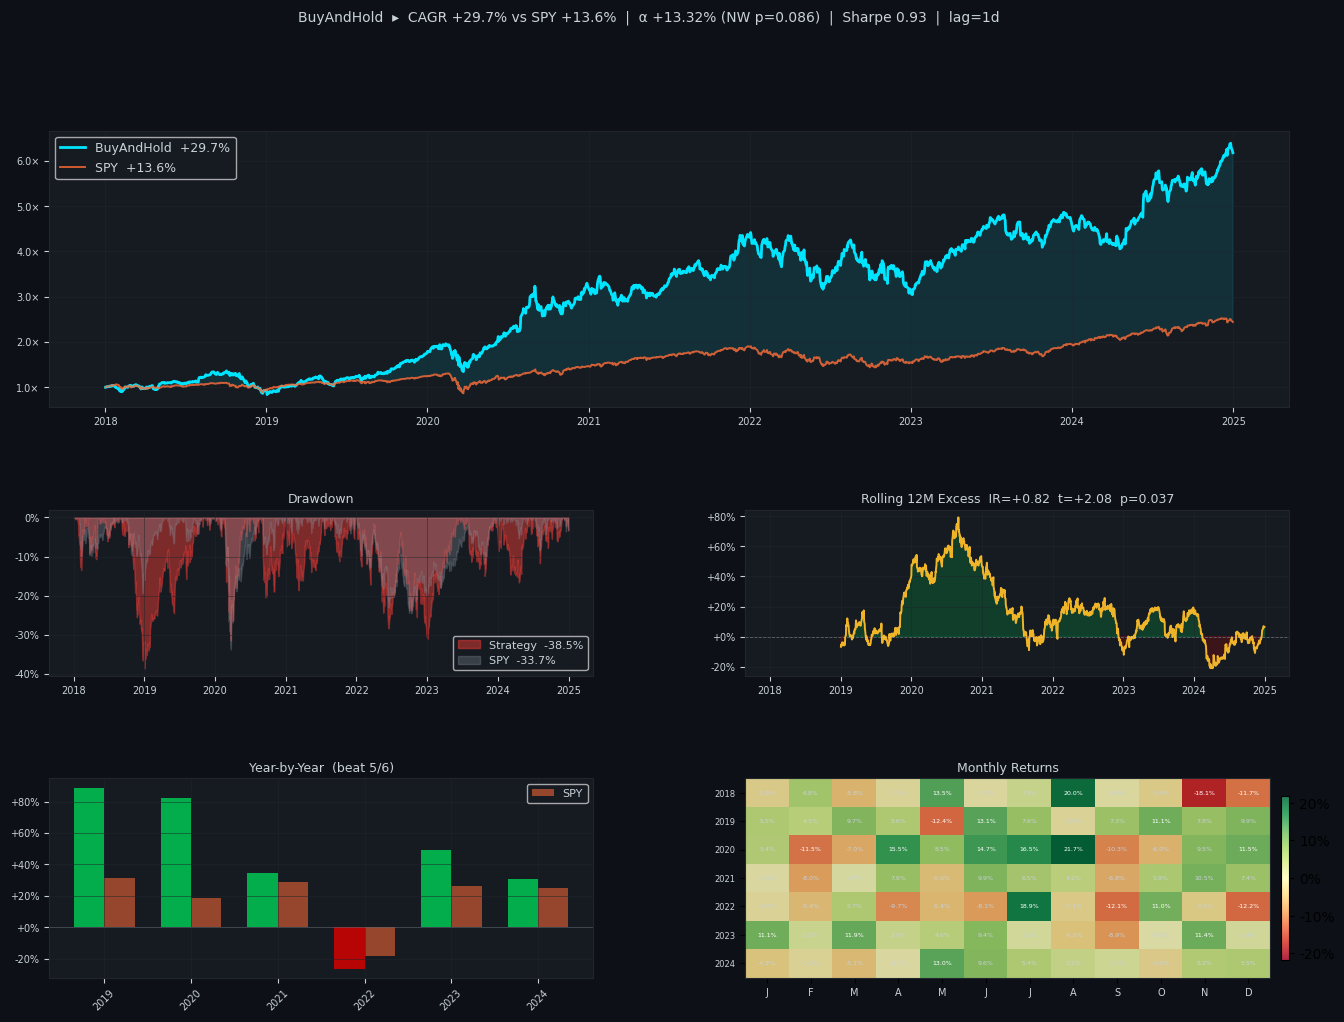

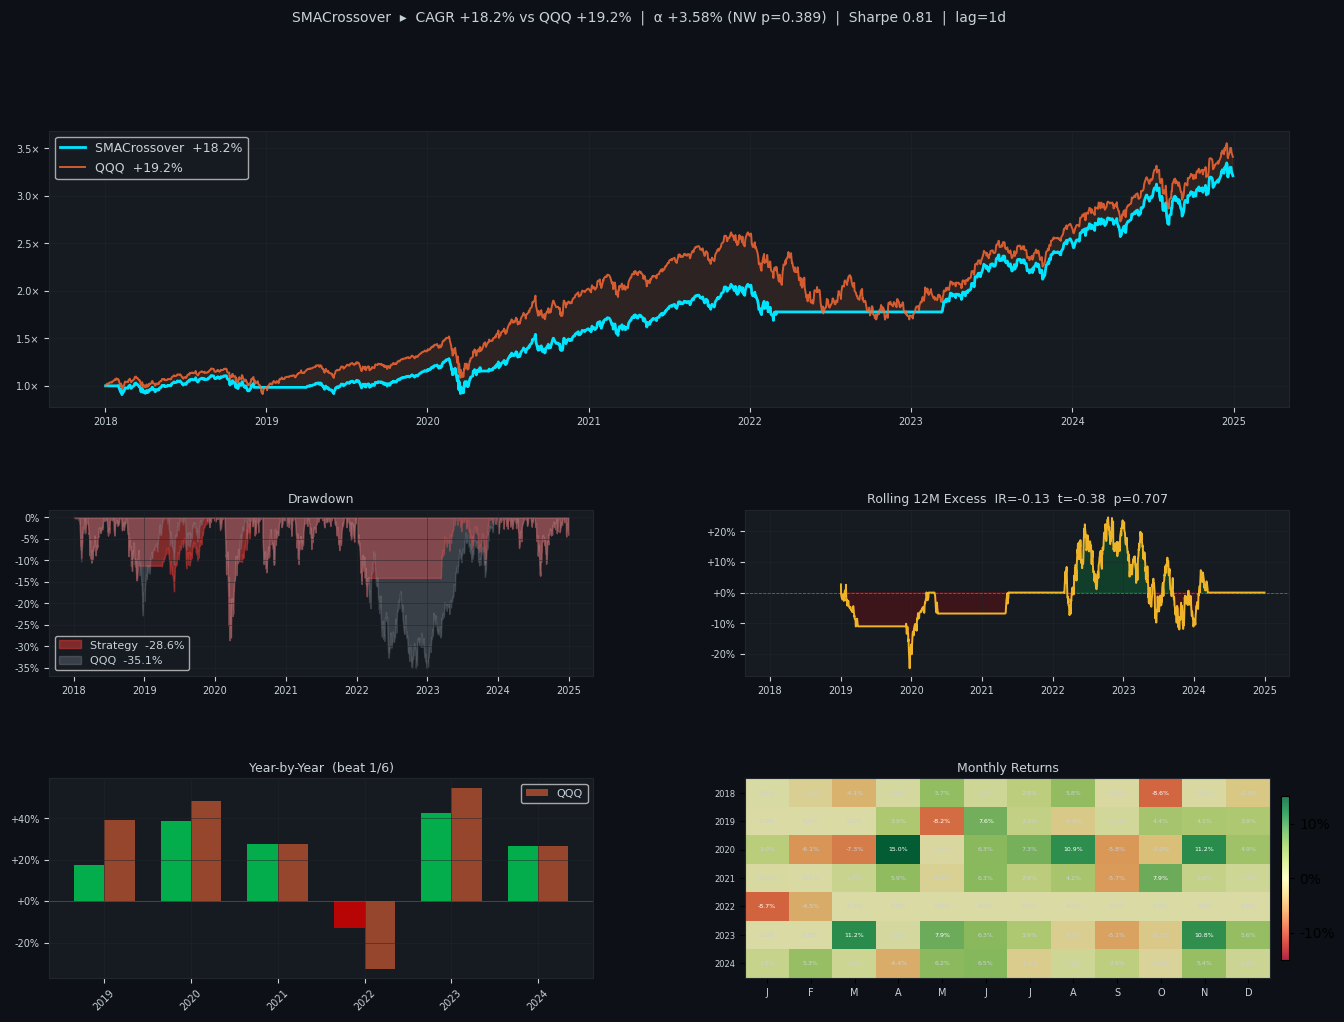

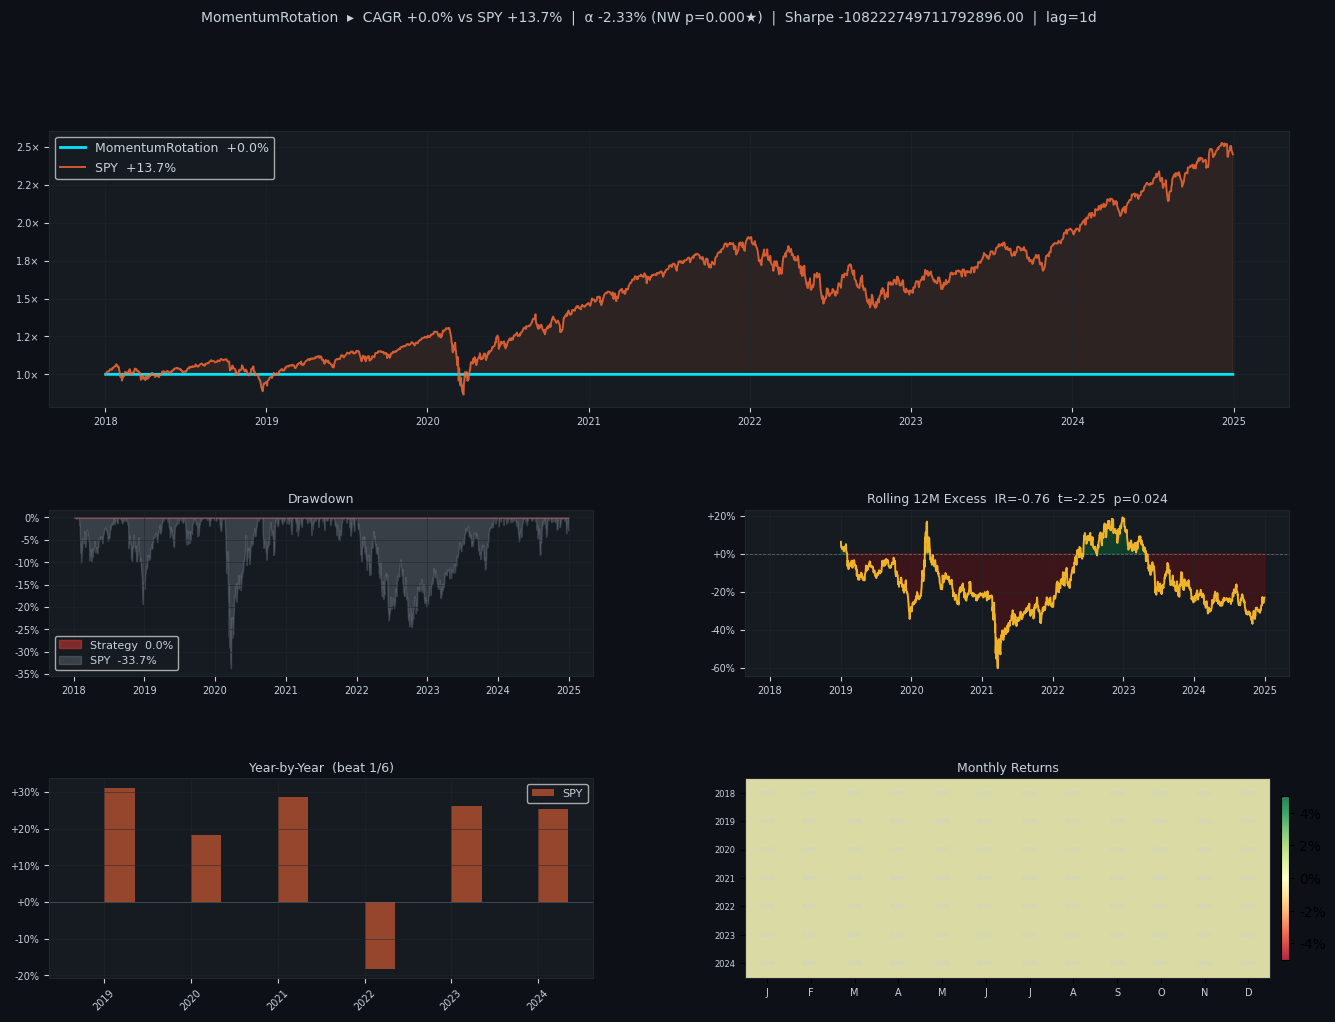

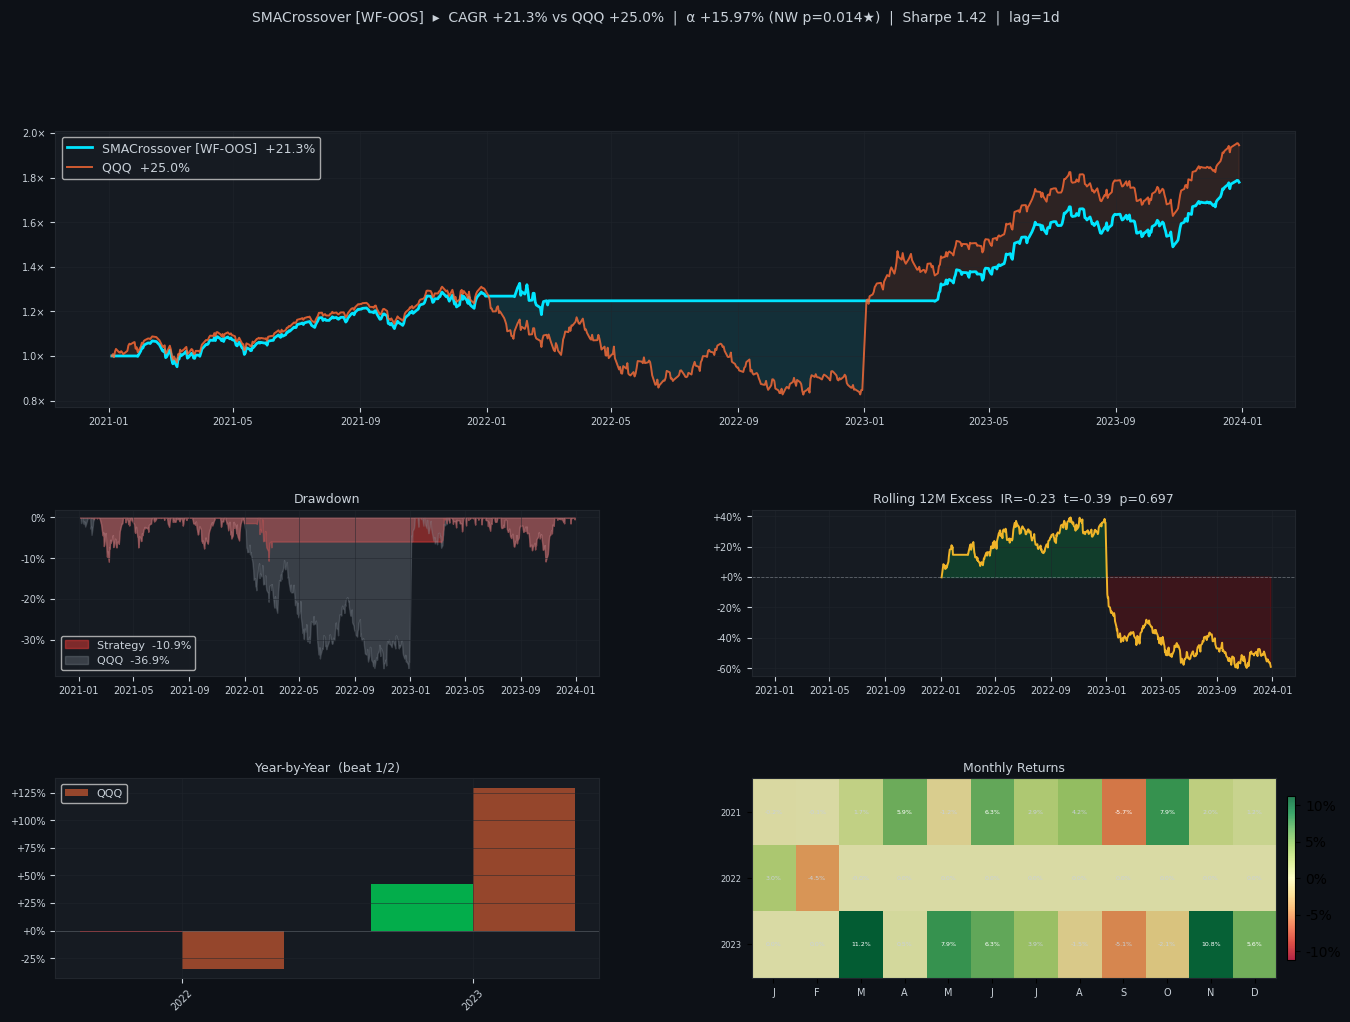

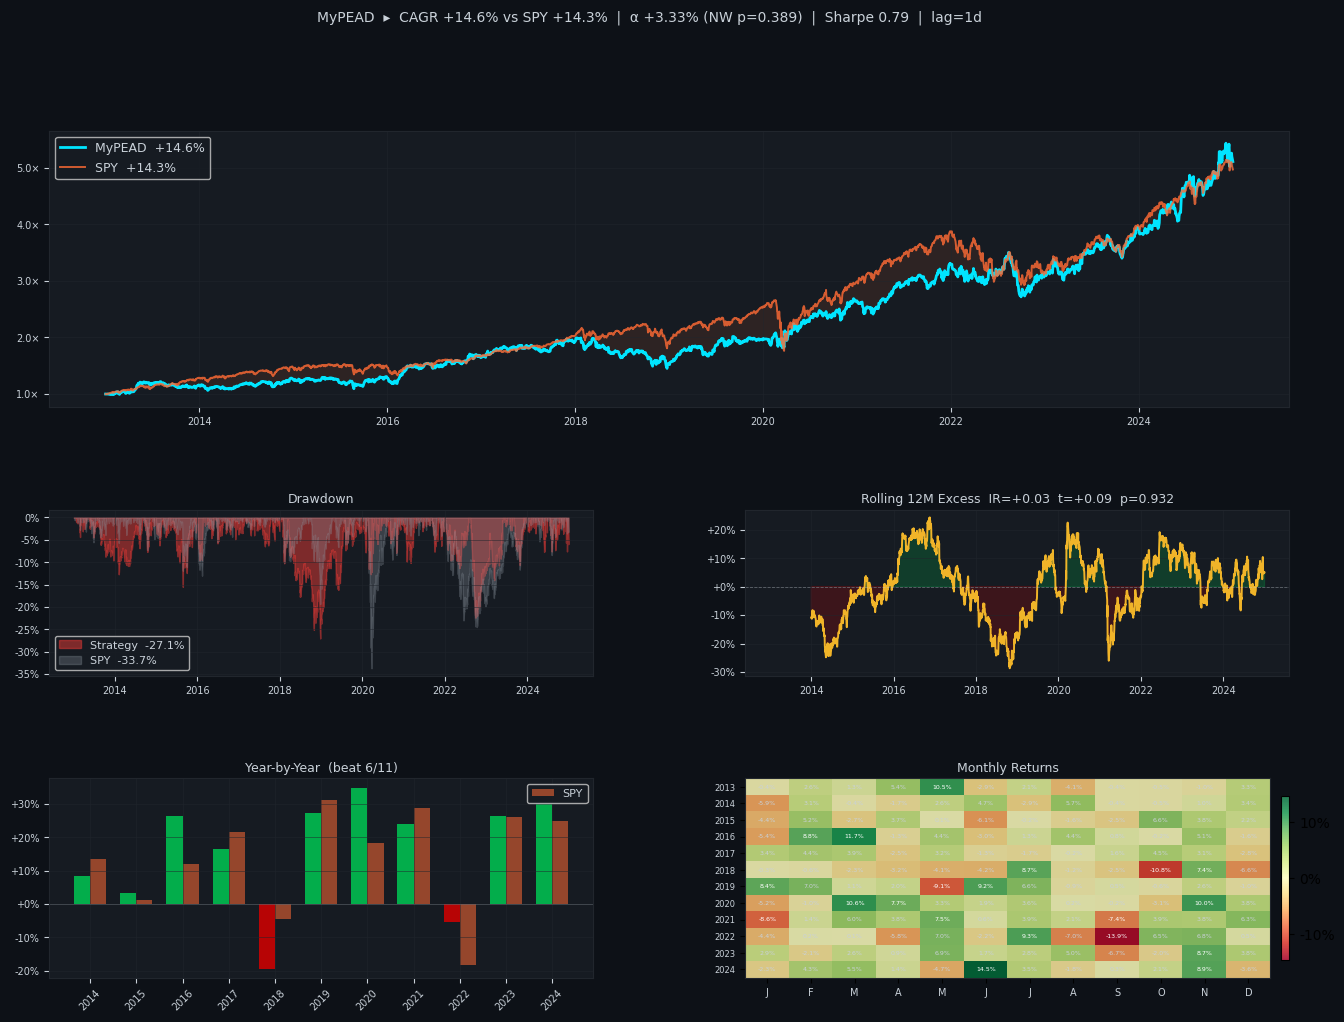


All done.


In [63]:
"""
example_strategies.py  v3
─────────────────────────────────────────────────────────────────────────
Four strategies showing the full API — from one-liner to PEAD.

All strategy config lives on the class.  Run any of them with:
    result = StrategyName.run("2018-01-01", "2024-01-01")

Run:
    python example_strategies.py
"""

from __future__ import annotations

import numpy as np
import pandas as pd



# ══════════════════════════════════════════════════════════════════════
# 1.  Buy & Hold
# ══════════════════════════════════════════════════════════════════════

class BuyAndHold(Backtest):
    """100% long one ticker for the entire period."""
    ticker    = "AAPL"
    benchmark = "SPY"

    def setup(self):
        self.add_ticker(self.ticker, lookback=0)

    def on_start(self):
        # Enter on day 1 and never touch it again
        pass

    def on_bar(self, date, prices):
        if not self.positions:
            self.enter(self.ticker, weight=1.0)


# ══════════════════════════════════════════════════════════════════════
# 2.  SMA Crossover
#     Look-ahead note: signal at T-close, fill at (T+1)-close (lag=1)
# ══════════════════════════════════════════════════════════════════════

class SMACrossover(Backtest):
    benchmark     = "QQQ"
    commission    = 0.001
    execution_lag = 1
    ticker        = "QQQ"
    fast          = 50
    slow          = 200

    def setup(self):
        self.add_ticker(self.ticker, lookback=self.slow + 60)

    def on_bar(self, date, prices):
        close   = self.data(self.ticker)["Close"]
        if len(close) < self.slow:
            return
        fast_ma = close.iloc[-self.fast:].mean()
        slow_ma = close.iloc[-self.slow:].mean()

        if fast_ma > slow_ma:
            if self.ticker not in self.positions:
                self.enter(self.ticker, weight=1.0)
        else:
            self.exit(self.ticker)


# ══════════════════════════════════════════════════════════════════════
# 3.  Monthly Momentum Rotation  (fixed ETF universe)
# ══════════════════════════════════════════════════════════════════════

class MomentumRotation(Backtest):
    benchmark      = "SPY"
    commission     = 0.001
    rebalance_freq = "ME"          # signals computed monthly
    execution_lag  = 1
    universe_list  = ["SPY","QQQ","IWM","EFA","TLT","GLD","VNQ"]
    top_n          = 3
    lookback_days  = 252

    def setup(self):
        for t in self.universe_list:
            self.add_ticker(t, lookback=self.lookback_days + 30)

    def on_bar(self, date, prices):
        scores = {}
        for t in self.universe_list:
            close = self.data(t)["Close"]
            if len(close) >= self.lookback_days:
                scores[t] = close.iloc[-1] / close.iloc[-self.lookback_days] - 1

        if not scores:
            return

        winners = sorted(scores, key=scores.get, reverse=True)[:self.top_n]
        w = 1.0 / len(winners)
        self.set_weights({t: w for t in winners})


# ══════════════════════════════════════════════════════════════════════
# 4.  PEAD Strategy  (event-driven, external signal DataFrame)
#
#     This is the main demo of the new add_signals() flow.
#     Your signals_df should have at minimum:
#       - an entry date column (e.g. "entry_date")
#       - a ticker column      (e.g. "Ticker")
#       - a SUE column         (e.g. "SUE")
#       - optionally "Sector", "exit_close_date", etc.
#
#     The engine:
#       1. auto-fetches price data for every ticker in the DataFrame
#       2. on each simulation date, calls on_signal() for each matching row
#       3. calls on_bar() daily for position management (exits)
#
#     Bias controls:
#       - Survivorship : add_universe("SP500") resolves PIT membership
#       - Look-ahead   : signal date is the entry date; execution_lag=1
#                        so fills happen at next-day close
#       - After-hours  : pre-process your df so after-close announcements
#                        already have entry_date shifted to next bday
#                        (your Phase 7 code already does this correctly)
# ══════════════════════════════════════════════════════════════════════

class PEADStrategy(Backtest):
    """
    Post-Earnings Announcement Drift strategy driven by an external
    signal DataFrame.

    Parameters (set as class attributes or pass as kwargs to .run())
    ──────────────────────────────────────────────────────────────────
    signals_df     : pd.DataFrame  — your PEAD signal table
    date_col       : str           — column with the entry date
    ticker_col     : str           — column with the ticker
    sue_col        : str           — column with SUE score
    sector_col     : str | None    — filter to specific sectors
    allowed_sectors: set | None    — which sectors to trade
    exit_col       : str | None    — column with a pre-computed exit date
                                     (if None, exits after hold_days)
    hold_days      : int           — calendar days to hold if no exit_col
    n_positions    : int           — max concurrent positions
    min_sue        : float         — minimum SUE to enter
    benchmark      : str           — benchmark ticker
    commission     : float
    execution_lag  : int           — 1 = next-day fill (look-ahead safe)
    """

    # ── default config ────────────────────────────────────────────────
    signals_df:      pd.DataFrame  = None   # set before .run()
    date_col:        str           = "Date"
    ticker_col:      str           = "Ticker"
    sue_col:         str           = "SUE_Q"
    sector_col:      str           = "Sector"
    exit_col:        str           = "exit_close_date"
    allowed_sectors: set           = None   # None = all sectors
    hold_days:       int           = 22
    n_positions:     int           = 7
    min_sue:         float         = 0.0    # minimum SUE to trade
    benchmark        = "SPY"
    commission       = 0.0016
    slippage         = 0.0005
    execution_lag    = 1

    @property
    def max_positions(self):
        return self.n_positions

    def setup(self):
        if self.signals_df is None:
            raise ValueError("Set PEADStrategy.signals_df before calling .run()")

        df = self.signals_df.copy()

        # Sector filter
        if self.allowed_sectors and self.sector_col in df.columns:
            df = df[df[self.sector_col].isin(self.allowed_sectors)]

        # SUE filter
        if self.sue_col in df.columns:
            df = df[df[self.sue_col] >= self.min_sue]

        # Benchmark always in bundle
        self.add_ticker(self.benchmark, lookback=0)

        # Register the signal DataFrame
        # auto_fetch=True → engine downloads prices for every unique ticker
        self.add_signals(
            df            = df,
            date_col      = self.date_col,
            ticker_col    = self.ticker_col,
            auto_fetch    = True,
            lookback      = 5,
            name          = "PEAD",
        )

        # Optional: PIT S&P 500 membership guard
        self.add_universe("SP500")
        # (comment back in to enable survivorship bias control)

    def on_signal(self, date, signal, prices):
        """Open a new position when a PEAD signal arrives."""
        ticker = signal.get(self.ticker_col)
        sue    = signal.get(self.sue_col, 0)

        if not ticker or ticker not in prices:
            return

        # Optionally enforce PIT universe membership
        if self.universe is not None and ticker not in self.universe:
            return

        # Don't double-enter
        if ticker in self.positions:
            return

        # Store the pre-computed exit date from the signal df (if present)
        exit_date = signal.get(self.exit_col)
        tag = (f"SUE={sue:.2f}|exit="
               f"{pd.Timestamp(exit_date).date() if pd.notna(exit_date) else 'hold'}")

        # Size equally across max_positions slots
        slot_weight = 1.0 / self.n_positions
        self.enter(ticker, weight=slot_weight, tag=tag)

    def on_bar(self, date, prices):
        """Exit positions that have reached their hold period."""
        for ticker, pos in list(self.positions.items()):
            # Exit at pre-computed exit date if available
            exit_date_str = pos.tag.split("exit=")[-1] if pos.tag else "hold"
            if exit_date_str != "hold":
                try:
                    exit_date = pd.Timestamp(exit_date_str)
                    if date >= exit_date:
                        self.exit(ticker)
                        continue
                except Exception:
                    pass

            # Fallback: exit after hold_days calendar days
            if pos.age_days >= self.hold_days:
                self.exit(ticker)

    def on_end(self):
        """Close any positions still open at the end of the simulation."""
        self.exit_all()


# ══════════════════════════════════════════════════════════════════════
# HOW TO ATTACH AN EXTERNAL SIGNAL DATAFRAME TO PEAD
# ══════════════════════════════════════════════════════════════════════
#
# Option A — set the class attribute before running:
#
#     import pandas as pd
#     PEADStrategy.signals_df = pd.read_parquet("my_pead_signals.parquet")
#     result = PEADStrategy.run("2013-01-01", "2025-01-01")
#
# Option B — subclass and hard-code the df path:
#
#     class MyPEAD(PEADStrategy):
#         signals_df     = pd.read_parquet("my_pead_signals.parquet")
#         allowed_sectors= {"Technology", "Industrials"}
#         n_positions    = 7
#         min_sue        = 1.5
#
#     result = MyPEAD.run("2013-01-01", "2025-01-01")
#     result.summary()
#     result.plot(save_path="pead_results.png")
#
# Option C — one-off kwargs override (run() passes kwargs to setattr):
#
#     result = PEADStrategy.run(
#         "2013-01-01", "2025-01-01",
#         signals_df      = my_df,
#         allowed_sectors = {"Technology"},
#         n_positions     = 5,
#         commission      = 0.0016,
#     )
#
# ══════════════════════════════════════════════════════════════════════


# ══════════════════════════════════════════════════════════════════════
# Entry point — runs the price-only strategies; PEAD requires your df
# ══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    START = "2018-01-01"
    END   = "2024-12-31"

    # ── 1: Buy & Hold ─────────────────────────────────────────────────
    print("\n── Strategy 1: Buy & Hold AAPL ──")
    r1 = BuyAndHold.run(START, END)
    r1.summary()
    r1.plot(show=False)

    # ── 2: SMA Crossover ──────────────────────────────────────────────
    print("\n── Strategy 2: SMA Crossover QQQ (50/200) ──")
    r2 = SMACrossover.run(START, END)
    r2.summary()
    r2.plot(show=False)

    # ── 3: Momentum Rotation ──────────────────────────────────────────
    print("\n── Strategy 3: Momentum Rotation (monthly, top-3 ETFs) ──")
    r3 = MomentumRotation.run(START, END)
    r3.summary()
    r3.plot(show=False)

    # ── 4: Walk-Forward on SMA ────────────────────────────────────────
    print("\n── Walk-Forward: SMA Crossover (3yr train / 1yr OOS) ──")
    wf       = WalkForward(SMACrossover, train_years=3, test_years=1)
    oos, folds = wf.run(START, END)
    oos.summary()
    oos.plot(show=False)

    # ── PEAD (requires your signals df) ───────────────────────────────
    # Uncomment once you have a signal DataFrame:
    #
    import sqlite3
    conn = sqlite3.connect("pead_clean.db")

    df   = pd.read_sql("SELECT * FROM pead_clean", conn)
    conn.close()
    
    class MyPEAD(PEADStrategy):
          signals_df      = df
          allowed_sectors = {"Technology", "Industrials"}
          n_positions     = 7
          min_sue         = 0
    
    r_pead = MyPEAD.run("2013-01-01", "2025-01-01")
    r_pead.summary()
    r_pead.plot()

    print("\nAll done.")
